<a href="https://colab.research.google.com/github/JuanLoaiza/ALM_reservoir-water-quality/blob/main/notebooks/PALM_Land_Use_Change_Analysis_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Analisis de cambio de uso de suelo 2013-2017 completa

In [2]:
!pip install rasterio pandas openpyxl

import rasterio
import numpy as np
import pandas as pd
from google.colab import drive
from IPython.display import display
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import os

drive.mount('/content/drive')

Mounted at /content/drive



 MATRIZ DE TRANSICIÓN 2013–2015 (pixeles):


,Clase 1,Clase 2,Clase 3,Clase 4,Clase 5
Clase 1,60379,0,87,1,8
Clase 2,39,37332,2,17706,0
Clase 3,7631,593,72769,21779,124
Clase 4,5092,100618,32799,655369,38
Clase 5,35816,56,2074,2672,223



 MATRIZ DE TRANSICIÓN 2013–2015 (ha):


,Clase 1,Clase 2,Clase 3,Clase 4,Clase 5
Clase 1,5434.11,0.00,7.83,0.09,0.72
Clase 2,3.51,3359.88,0.18,1593.54,0.00
Clase 3,686.79,53.37,6549.21,1960.11,11.16
Clase 4,458.28,9055.62,2951.91,58983.21,3.42
Clase 5,3223.44,5.04,186.66,240.48,20.07



 TABLA RESUMEN DE CAMBIOS 2013–2015:


,Área Inicial (ha),Área Final (ha),Persistencia (ha),Pérdida (ha),Ganancia (ha),Cambio Neto (ha),Cambio Total (ha),% de Cambio,Tasa Anual (%)
Clase,,,,,,,,,
1,5442.75,9806.13,5434.11,8.64,4372.02,4363.38,4380.66,80.49,40.24
2,4957.11,12473.91,3359.88,1597.23,9114.03,7516.80,10711.26,216.08,108.04
3,9260.64,9695.79,6549.21,2711.43,3146.58,435.15,5858.01,63.26,31.63
4,71452.44,62777.43,58983.21,12469.23,3794.22,-8675.01,16263.45,22.76,11.38
5,3675.69,35.37,20.07,3655.62,15.30,-3640.32,3670.92,99.87,49.94


Archivo Excel exportado correctamente en:
/content/drive/MyDrive/Analisis_cambio_uso_suelo/analisis_cambio_uso_suelo_2013_2015.xlsx


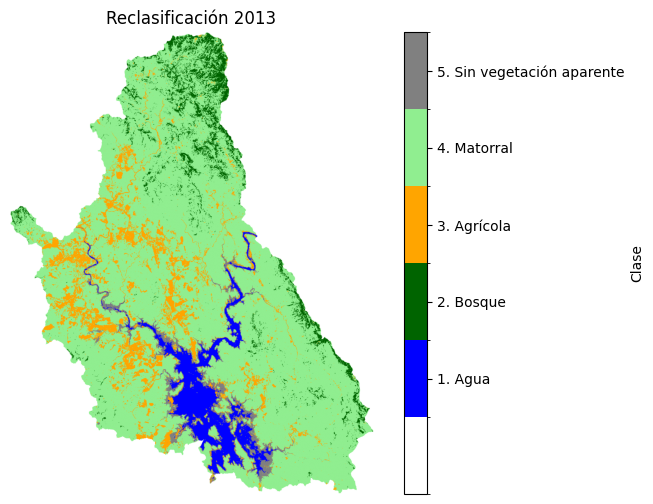

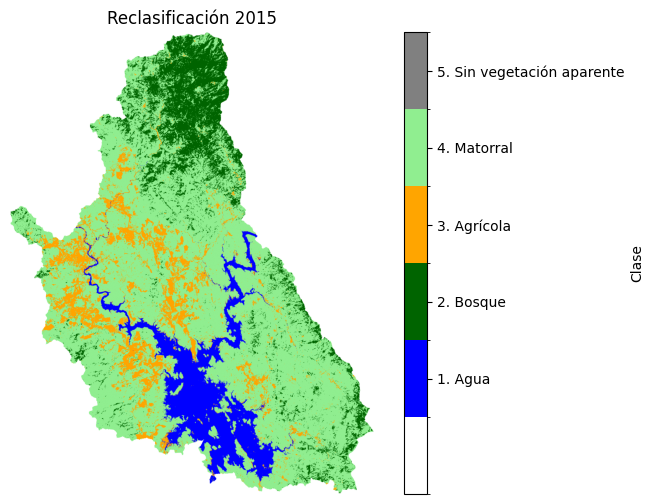

In [3]:

ruta_raster_1 = '/content/drive/MyDrive/EarthEngine/reclasificada_2013_completa.tif'
ruta_raster_2 = '/content/drive/MyDrive/EarthEngine/reclasificada_2015_completa.tif'

nombre_raster_1 = '2013'
nombre_raster_2 = '2015'

periodo_anios = 2

carpeta_salida = '/content/drive/MyDrive/Analisis_cambio_uso_suelo'
os.makedirs(carpeta_salida, exist_ok=True)

salida_excel = os.path.join(
    carpeta_salida,
    f'analisis_cambio_uso_suelo_{nombre_raster_1}_{nombre_raster_2}.xlsx'
)

def read_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1)
        nodata = src.nodata
        transform = src.transform
        crs = src.crs
        shape = data.shape
    return data, nodata, transform, crs, shape

raster_1, nodata_1, transform_1, crs_1, shape_1 = read_raster(ruta_raster_1)
raster_2, nodata_2, transform_2, crs_2, shape_2 = read_raster(ruta_raster_2)

if shape_1 != shape_2:
    raise ValueError("Los raster no tienen el mismo tamaño.")

if transform_1 != transform_2:
    print("Advertencia: los raster tienen diferente alineación espacial o resolución.")

if crs_1 != crs_2:
    print("Advertencia: los raster tienen diferente sistema de coordenadas.")


flat_1 = raster_1.flatten()
flat_2 = raster_2.flatten()

mask = (flat_1 > 0) & (flat_2 > 0)

if nodata_1 is not None:
    mask = mask & (flat_1 != nodata_1)

if nodata_2 is not None:
    mask = mask & (flat_2 != nodata_2)

flat_1 = flat_1[mask]
flat_2 = flat_2[mask]

clases = np.unique(np.concatenate((flat_1, flat_2)))
clases.sort()

n = len(clases)
clase_dict = {v: i for i, v in enumerate(clases)}

matriz = np.zeros((n, n), dtype=int)

for c1, c2 in zip(flat_1, flat_2):
    i = clase_dict[c1]
    j = clase_dict[c2]
    matriz[i, j] += 1

df_matriz_pixeles = pd.DataFrame(
    matriz,
    index=[f'Clase {int(c)}' for c in clases],
    columns=[f'Clase {int(c)}' for c in clases]
)

pixel_area_ha = 30 * 30 / 10000
matriz_ha = matriz * pixel_area_ha

df_matriz_ha = pd.DataFrame(
    matriz_ha,
    index=[f'Clase {int(c)}' for c in clases],
    columns=[f'Clase {int(c)}' for c in clases]
)

resultados = []

for i, clase in enumerate(clases):
    fila = matriz[i, :]
    col = matriz[:, i]

    inicial = fila.sum()
    final = col.sum()
    persistencia = matriz[i, i]
    perdida = inicial - persistencia
    ganancia = final - persistencia
    cambio_neto = ganancia - perdida
    cambio_total = ganancia + perdida

    porcentaje_cambio = cambio_total / inicial * 100 if inicial > 0 else 0
    tasa_anual = porcentaje_cambio / periodo_anios if periodo_anios > 0 else 0

    resultados.append({
        'Clase': int(clase),
        'Área Inicial (ha)': inicial * pixel_area_ha,
        'Área Final (ha)': final * pixel_area_ha,
        'Persistencia (ha)': persistencia * pixel_area_ha,
        'Pérdida (ha)': perdida * pixel_area_ha,
        'Ganancia (ha)': ganancia * pixel_area_ha,
        'Cambio Neto (ha)': cambio_neto * pixel_area_ha,
        'Cambio Total (ha)': cambio_total * pixel_area_ha,
        '% de Cambio': porcentaje_cambio,
        'Tasa Anual (%)': tasa_anual
    })

df_resultados = pd.DataFrame(resultados).set_index('Clase')

print(f"\n MATRIZ DE TRANSICIÓN {nombre_raster_1}–{nombre_raster_2} (pixeles):")
display(df_matriz_pixeles)

print(f"\n MATRIZ DE TRANSICIÓN {nombre_raster_1}–{nombre_raster_2} (ha):")
display(df_matriz_ha.round(2))

print(f"\n TABLA RESUMEN DE CAMBIOS {nombre_raster_1}–{nombre_raster_2}:")
display(df_resultados.round(2))

with pd.ExcelWriter(salida_excel, engine='openpyxl') as writer:
    df_matriz_pixeles.to_excel(writer, sheet_name='Matriz_transicion_pixeles')
    df_matriz_ha.round(4).to_excel(writer, sheet_name='Matriz_transicion_ha')
    df_resultados.round(4).to_excel(writer, sheet_name='Resumen_cambios')

print("Archivo Excel exportado correctamente en:")
print(salida_excel)

colores = [
    'white',
    'blue',
    'darkgreen',
    'orange',
    'lightgreen',
    'gray'
]

etiquetas = [
    '1. Agua',
    '2. Bosque',
    '3. Agrícola',
    '4. Matorral',
    '5. Sin vegetación aparente'
]

cmap = ListedColormap(colores)
boundaries = np.arange(0, 7) - 0.5
norm = BoundaryNorm(boundaries, cmap.N)

def plot_classification_colored(data, title):
    plt.figure(figsize=(8, 6))
    im = plt.imshow(data, cmap=cmap, norm=norm)
    cbar = plt.colorbar(im, ticks=np.arange(1, 6))
    cbar.set_label('Clase')
    cbar.ax.set_yticklabels(etiquetas)
    plt.title(title)
    plt.axis('off')
    plt.show()

plot_classification_colored(raster_1, f'Reclasificación {nombre_raster_1}')
plot_classification_colored(raster_2, f'Reclasificación {nombre_raster_2}')

#Analisis de cambio de uso de suelo ZONA 1 2013-2015


 MATRIZ DE TRANSICIÓN 2013–2015 (pixeles):


,Clase 1,Clase 2,Clase 3,Clase 4,Clase 5
Clase 1,11153,0,2,1,1
Clase 2,10,8805,2,9184,0
Clase 3,1606,49,15942,4267,21
Clase 4,1200,21964,8054,237869,19
Clase 5,7192,4,469,710,48



 MATRIZ DE TRANSICIÓN 2013–2015 (ha):


,Clase 1,Clase 2,Clase 3,Clase 4,Clase 5
Clase 1,1003.77,0.00,0.18,0.09,0.09
Clase 2,0.90,792.45,0.18,826.56,0.00
Clase 3,144.54,4.41,1434.78,384.03,1.89
Clase 4,108.00,1976.76,724.86,21408.21,1.71
Clase 5,647.28,0.36,42.21,63.90,4.32



 TABLA RESUMEN DE CAMBIOS 2013–2015:


,Área Inicial (ha),Área Final (ha),Persistencia (ha),Pérdida (ha),Ganancia (ha),Cambio Neto (ha),Cambio Total (ha),% de Cambio,Tasa Anual (%)
Clase,,,,,,,,,
1,1004.13,1904.49,1003.77,0.36,900.72,900.36,901.08,89.74,44.87
2,1620.09,2773.98,792.45,827.64,1981.53,1153.89,2809.17,173.40,86.70
3,1969.65,2202.21,1434.78,534.87,767.43,232.56,1302.30,66.12,33.06
4,24219.54,22682.79,21408.21,2811.33,1274.58,-1536.75,4085.91,16.87,8.44
5,758.07,8.01,4.32,753.75,3.69,-750.06,757.44,99.92,49.96


Archivo Excel exportado correctamente en:
/content/drive/MyDrive/Analisis_cambio_uso_suelo/analisis_cambio_uso_suelo_2013_2015_zona - 1.xlsx


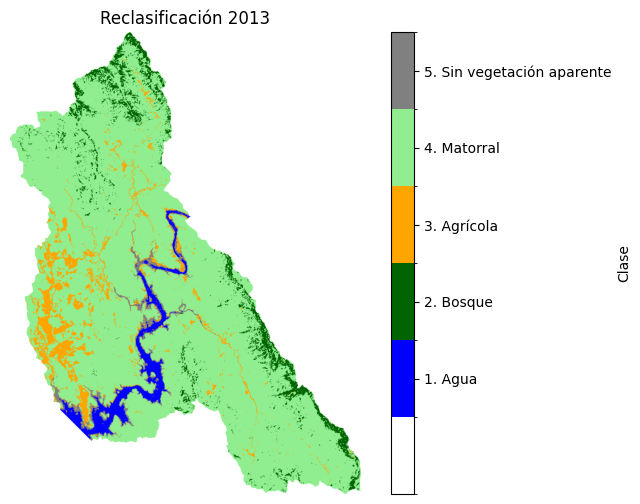

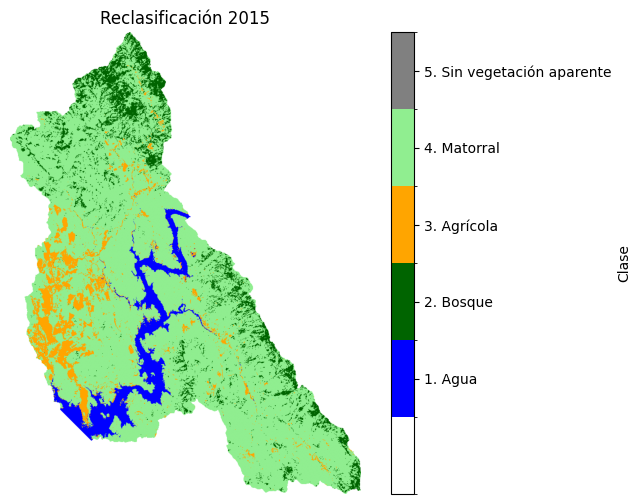

In [4]:
# @title
ruta_raster_1 = '/content/drive/MyDrive/EarthEngine/reclas_zona1_2013.tif'
ruta_raster_2 = '/content/drive/MyDrive/EarthEngine/reclas_zona1_2015.tif'

nombre_raster_1 = '2013'
nombre_raster_2 = '2015'
zona = 'zona - 1'

periodo_anios = 2

carpeta_salida = '/content/drive/MyDrive/Analisis_cambio_uso_suelo'
os.makedirs(carpeta_salida, exist_ok=True)

salida_excel = os.path.join(
    carpeta_salida,
    f'analisis_cambio_uso_suelo_{nombre_raster_1}_{nombre_raster_2}_{zona}.xlsx'
)

def read_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1)
        nodata = src.nodata
        transform = src.transform
        crs = src.crs
        shape = data.shape
    return data, nodata, transform, crs, shape

raster_1, nodata_1, transform_1, crs_1, shape_1 = read_raster(ruta_raster_1)
raster_2, nodata_2, transform_2, crs_2, shape_2 = read_raster(ruta_raster_2)

if shape_1 != shape_2:
    raise ValueError("Los raster no tienen el mismo tamaño.")

if transform_1 != transform_2:
    print("Advertencia: los raster tienen diferente alineación espacial o resolución.")

if crs_1 != crs_2:
    print("Advertencia: los raster tienen diferente sistema de coordenadas.")


flat_1 = raster_1.flatten()
flat_2 = raster_2.flatten()

mask = (flat_1 > 0) & (flat_2 > 0)

if nodata_1 is not None:
    mask = mask & (flat_1 != nodata_1)

if nodata_2 is not None:
    mask = mask & (flat_2 != nodata_2)

flat_1 = flat_1[mask]
flat_2 = flat_2[mask]

clases = np.unique(np.concatenate((flat_1, flat_2)))
clases.sort()

n = len(clases)
clase_dict = {v: i for i, v in enumerate(clases)}

matriz = np.zeros((n, n), dtype=int)

for c1, c2 in zip(flat_1, flat_2):
    i = clase_dict[c1]
    j = clase_dict[c2]
    matriz[i, j] += 1

df_matriz_pixeles = pd.DataFrame(
    matriz,
    index=[f'Clase {int(c)}' for c in clases],
    columns=[f'Clase {int(c)}' for c in clases]
)

pixel_area_ha = 30 * 30 / 10000
matriz_ha = matriz * pixel_area_ha

df_matriz_ha = pd.DataFrame(
    matriz_ha,
    index=[f'Clase {int(c)}' for c in clases],
    columns=[f'Clase {int(c)}' for c in clases]
)

resultados = []

for i, clase in enumerate(clases):
    fila = matriz[i, :]
    col = matriz[:, i]

    inicial = fila.sum()
    final = col.sum()
    persistencia = matriz[i, i]
    perdida = inicial - persistencia
    ganancia = final - persistencia
    cambio_neto = ganancia - perdida
    cambio_total = ganancia + perdida

    porcentaje_cambio = cambio_total / inicial * 100 if inicial > 0 else 0
    tasa_anual = porcentaje_cambio / periodo_anios if periodo_anios > 0 else 0

    resultados.append({
        'Clase': int(clase),
        'Área Inicial (ha)': inicial * pixel_area_ha,
        'Área Final (ha)': final * pixel_area_ha,
        'Persistencia (ha)': persistencia * pixel_area_ha,
        'Pérdida (ha)': perdida * pixel_area_ha,
        'Ganancia (ha)': ganancia * pixel_area_ha,
        'Cambio Neto (ha)': cambio_neto * pixel_area_ha,
        'Cambio Total (ha)': cambio_total * pixel_area_ha,
        '% de Cambio': porcentaje_cambio,
        'Tasa Anual (%)': tasa_anual
    })

df_resultados = pd.DataFrame(resultados).set_index('Clase')

print(f"\n MATRIZ DE TRANSICIÓN {nombre_raster_1}–{nombre_raster_2} (pixeles):")
display(df_matriz_pixeles)

print(f"\n MATRIZ DE TRANSICIÓN {nombre_raster_1}–{nombre_raster_2} (ha):")
display(df_matriz_ha.round(2))

print(f"\n TABLA RESUMEN DE CAMBIOS {nombre_raster_1}–{nombre_raster_2}:")
display(df_resultados.round(2))

with pd.ExcelWriter(salida_excel, engine='openpyxl') as writer:
    df_matriz_pixeles.to_excel(writer, sheet_name='Matriz_transicion_pixeles')
    df_matriz_ha.round(4).to_excel(writer, sheet_name='Matriz_transicion_ha')
    df_resultados.round(4).to_excel(writer, sheet_name='Resumen_cambios')

print("Archivo Excel exportado correctamente en:")
print(salida_excel)

colores = [
    'white',
    'blue',
    'darkgreen',
    'orange',
    'lightgreen',
    'gray'
]

etiquetas = [
    '1. Agua',
    '2. Bosque',
    '3. Agrícola',
    '4. Matorral',
    '5. Sin vegetación aparente'
]

cmap = ListedColormap(colores)
boundaries = np.arange(0, 7) - 0.5
norm = BoundaryNorm(boundaries, cmap.N)

def plot_classification_colored(data, title):
    plt.figure(figsize=(8, 6))
    im = plt.imshow(data, cmap=cmap, norm=norm)
    cbar = plt.colorbar(im, ticks=np.arange(1, 6))
    cbar.set_label('Clase')
    cbar.ax.set_yticklabels(etiquetas)
    plt.title(title)
    plt.axis('off')
    plt.show()

plot_classification_colored(raster_1, f'Reclasificación {nombre_raster_1}')
plot_classification_colored(raster_2, f'Reclasificación {nombre_raster_2}')

#Analsis de cambio de uso de suelo ZONA 1 2015-2017


 MATRIZ DE TRANSICIÓN 2015–2017 (pixeles):


,Clase 1,Clase 2,Clase 3,Clase 4,Clase 5
Clase 1,19861,4,811,398,87
Clase 2,6,13320,490,17011,0
Clase 3,387,42,20077,3938,26
Clase 4,1541,18696,11660,220124,10
Clase 5,25,0,35,5,24



 MATRIZ DE TRANSICIÓN 2015–2017 (ha):


,Clase 1,Clase 2,Clase 3,Clase 4,Clase 5
Clase 1,1787.49,0.36,72.99,35.82,7.83
Clase 2,0.54,1198.80,44.10,1530.99,0.00
Clase 3,34.83,3.78,1806.93,354.42,2.34
Clase 4,138.69,1682.64,1049.40,19811.16,0.90
Clase 5,2.25,0.00,3.15,0.45,2.16



 TABLA RESUMEN DE CAMBIOS 2015–2017:


,Área Inicial (ha),Área Final (ha),Persistencia (ha),Pérdida (ha),Ganancia (ha),Cambio Neto (ha),Cambio Total (ha),% de Cambio,Tasa Anual (%)
Clase,,,,,,,,,
1,1904.49,1963.80,1787.49,117.00,176.31,59.31,293.31,15.40,7.70
2,2774.43,2885.58,1198.80,1575.63,1686.78,111.15,3262.41,117.59,58.79
3,2202.30,2976.57,1806.93,395.37,1169.64,774.27,1565.01,71.06,35.53
4,22682.79,21732.84,19811.16,2871.63,1921.68,-949.95,4793.31,21.13,10.57
5,8.01,13.23,2.16,5.85,11.07,5.22,16.92,211.24,105.62


Archivo Excel exportado correctamente en:
/content/drive/MyDrive/Analisis_cambio_uso_suelo/analisis_cambio_uso_suelo_2015_2017_zona - 1.xlsx


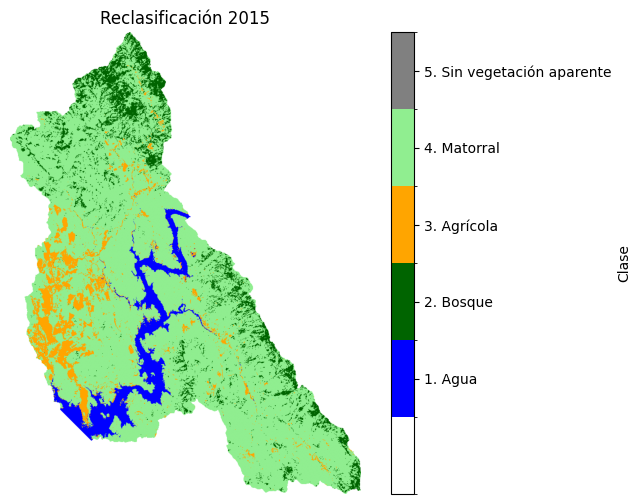

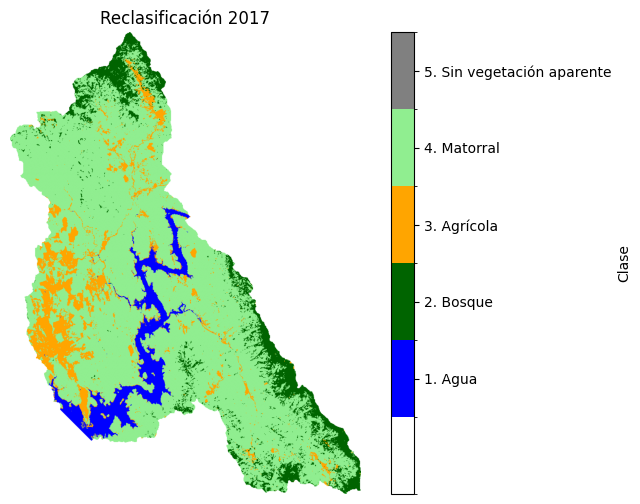

In [ ]:
# @title
ruta_raster_1 = '/content/drive/MyDrive/EarthEngine/reclas_zona1_2015_X.tif'
ruta_raster_2 = '/content/drive/MyDrive/EarthEngine/reclas_zona1_2017_X.tif'

nombre_raster_1 = '2015'
nombre_raster_2 = '2017'
zona = 'zona - 1'

periodo_anios = 2

carpeta_salida = '/content/drive/MyDrive/Analisis_cambio_uso_suelo'
os.makedirs(carpeta_salida, exist_ok=True)

salida_excel = os.path.join(
    carpeta_salida,
    f'analisis_cambio_uso_suelo_{nombre_raster_1}_{nombre_raster_2}_{zona}.xlsx'
)

def read_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1)
        nodata = src.nodata
        transform = src.transform
        crs = src.crs
        shape = data.shape
    return data, nodata, transform, crs, shape

raster_1, nodata_1, transform_1, crs_1, shape_1 = read_raster(ruta_raster_1)
raster_2, nodata_2, transform_2, crs_2, shape_2 = read_raster(ruta_raster_2)

if shape_1 != shape_2:
    raise ValueError("Los raster no tienen el mismo tamaño.")

if transform_1 != transform_2:
    print("Advertencia: los raster tienen diferente alineación espacial o resolución.")

if crs_1 != crs_2:
    print("Advertencia: los raster tienen diferente sistema de coordenadas.")


flat_1 = raster_1.flatten()
flat_2 = raster_2.flatten()

mask = (flat_1 > 0) & (flat_2 > 0)

if nodata_1 is not None:
    mask = mask & (flat_1 != nodata_1)

if nodata_2 is not None:
    mask = mask & (flat_2 != nodata_2)

flat_1 = flat_1[mask]
flat_2 = flat_2[mask]

clases = np.unique(np.concatenate((flat_1, flat_2)))
clases.sort()

n = len(clases)
clase_dict = {v: i for i, v in enumerate(clases)}

matriz = np.zeros((n, n), dtype=int)

for c1, c2 in zip(flat_1, flat_2):
    i = clase_dict[c1]
    j = clase_dict[c2]
    matriz[i, j] += 1

df_matriz_pixeles = pd.DataFrame(
    matriz,
    index=[f'Clase {int(c)}' for c in clases],
    columns=[f'Clase {int(c)}' for c in clases]
)

pixel_area_ha = 30 * 30 / 10000
matriz_ha = matriz * pixel_area_ha

df_matriz_ha = pd.DataFrame(
    matriz_ha,
    index=[f'Clase {int(c)}' for c in clases],
    columns=[f'Clase {int(c)}' for c in clases]
)

resultados = []

for i, clase in enumerate(clases):
    fila = matriz[i, :]
    col = matriz[:, i]

    inicial = fila.sum()
    final = col.sum()
    persistencia = matriz[i, i]
    perdida = inicial - persistencia
    ganancia = final - persistencia
    cambio_neto = ganancia - perdida
    cambio_total = ganancia + perdida

    porcentaje_cambio = cambio_total / inicial * 100 if inicial > 0 else 0
    tasa_anual = porcentaje_cambio / periodo_anios if periodo_anios > 0 else 0

    resultados.append({
        'Clase': int(clase),
        'Área Inicial (ha)': inicial * pixel_area_ha,
        'Área Final (ha)': final * pixel_area_ha,
        'Persistencia (ha)': persistencia * pixel_area_ha,
        'Pérdida (ha)': perdida * pixel_area_ha,
        'Ganancia (ha)': ganancia * pixel_area_ha,
        'Cambio Neto (ha)': cambio_neto * pixel_area_ha,
        'Cambio Total (ha)': cambio_total * pixel_area_ha,
        '% de Cambio': porcentaje_cambio,
        'Tasa Anual (%)': tasa_anual
    })

df_resultados = pd.DataFrame(resultados).set_index('Clase')

print(f"\n MATRIZ DE TRANSICIÓN {nombre_raster_1}–{nombre_raster_2} (pixeles):")
display(df_matriz_pixeles)

print(f"\n MATRIZ DE TRANSICIÓN {nombre_raster_1}–{nombre_raster_2} (ha):")
display(df_matriz_ha.round(2))

print(f"\n TABLA RESUMEN DE CAMBIOS {nombre_raster_1}–{nombre_raster_2}:")
display(df_resultados.round(2))

with pd.ExcelWriter(salida_excel, engine='openpyxl') as writer:
    df_matriz_pixeles.to_excel(writer, sheet_name='Matriz_transicion_pixeles')
    df_matriz_ha.round(4).to_excel(writer, sheet_name='Matriz_transicion_ha')
    df_resultados.round(4).to_excel(writer, sheet_name='Resumen_cambios')

print("Archivo Excel exportado correctamente en:")
print(salida_excel)

colores = [
    'white',
    'blue',
    'darkgreen',
    'orange',
    'lightgreen',
    'gray'
]

etiquetas = [
    '1. Agua',
    '2. Bosque',
    '3. Agrícola',
    '4. Matorral',
    '5. Sin vegetación aparente'
]

cmap = ListedColormap(colores)
boundaries = np.arange(0, 7) - 0.5
norm = BoundaryNorm(boundaries, cmap.N)

def plot_classification_colored(data, title):
    plt.figure(figsize=(8, 6))
    im = plt.imshow(data, cmap=cmap, norm=norm)
    cbar = plt.colorbar(im, ticks=np.arange(1, 6))
    cbar.set_label('Clase')
    cbar.ax.set_yticklabels(etiquetas)
    plt.title(title)
    plt.axis('off')
    plt.show()

plot_classification_colored(raster_1, f'Reclasificación {nombre_raster_1}')
plot_classification_colored(raster_2, f'Reclasificación {nombre_raster_2}')

#Analisis de cambio de uso de suelo ZONA 2 2013-2015


 MATRIZ DE TRANSICIÓN 2013–2015 (pixeles):


,Clase 1,Clase 2,Clase 3,Clase 4,Clase 5
Clase 1,1499,0,72,0,1
Clase 2,24,27007,0,6841,0
Clase 3,783,517,39988,12816,10
Clase 4,239,66367,15082,223856,1
Clase 5,3797,45,573,924,7



 MATRIZ DE TRANSICIÓN 2013–2015 (ha):


,Clase 1,Clase 2,Clase 3,Clase 4,Clase 5
Clase 1,134.91,0.00,6.48,0.00,0.09
Clase 2,2.16,2430.63,0.00,615.69,0.00
Clase 3,70.47,46.53,3598.92,1153.44,0.90
Clase 4,21.51,5973.03,1357.38,20147.04,0.09
Clase 5,341.73,4.05,51.57,83.16,0.63



 TABLA RESUMEN DE CAMBIOS 2013–2015:


,Área Inicial (ha),Área Final (ha),Persistencia (ha),Pérdida (ha),Ganancia (ha),Cambio Neto (ha),Cambio Total (ha),% de Cambio,Tasa Anual (%)
Clase,,,,,,,,,
1,141.48,570.78,134.91,6.57,435.87,429.30,442.44,312.72,156.36
2,3048.48,8454.24,2430.63,617.85,6023.61,5405.76,6641.46,217.86,108.93
3,4870.26,5014.35,3598.92,1271.34,1415.43,144.09,2686.77,55.17,27.58
4,27499.05,21999.33,20147.04,7352.01,1852.29,-5499.72,9204.30,33.47,16.74
5,481.14,1.71,0.63,480.51,1.08,-479.43,481.59,100.09,50.05


Archivo Excel exportado correctamente en:
/content/drive/MyDrive/Analisis_cambio_uso_suelo/analisis_cambio_uso_suelo_2013_2015_zona - 2.xlsx


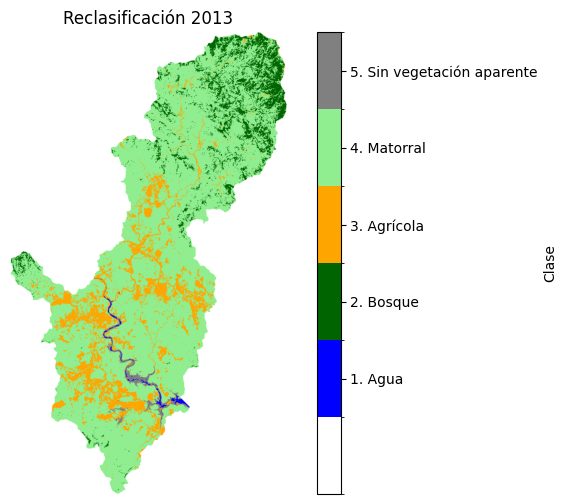

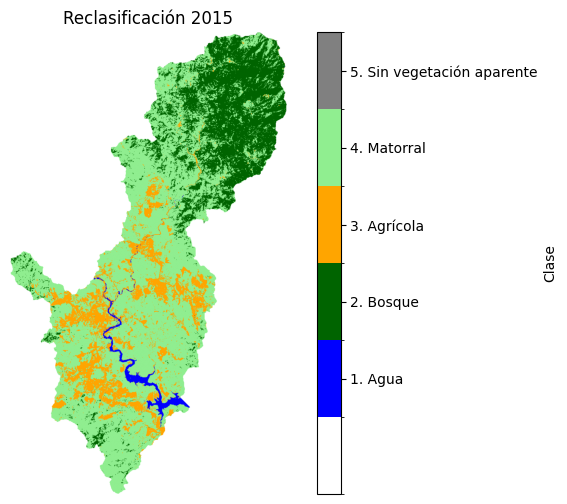

In [ ]:
# @title
ruta_raster_1 = '/content/drive/MyDrive/EarthEngine/reclas_zona2_2013_X.tif'
ruta_raster_2 = '/content/drive/MyDrive/EarthEngine/reclas_zona2_2015_X.tif'

nombre_raster_1 = '2013'
nombre_raster_2 = '2015'
zona = 'zona - 2'

periodo_anios = 2

carpeta_salida = '/content/drive/MyDrive/Analisis_cambio_uso_suelo'
os.makedirs(carpeta_salida, exist_ok=True)

salida_excel = os.path.join(
    carpeta_salida,
    f'analisis_cambio_uso_suelo_{nombre_raster_1}_{nombre_raster_2}_{zona}.xlsx'
)

def read_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1)
        nodata = src.nodata
        transform = src.transform
        crs = src.crs
        shape = data.shape
    return data, nodata, transform, crs, shape

raster_1, nodata_1, transform_1, crs_1, shape_1 = read_raster(ruta_raster_1)
raster_2, nodata_2, transform_2, crs_2, shape_2 = read_raster(ruta_raster_2)

if shape_1 != shape_2:
    raise ValueError("Los raster no tienen el mismo tamaño.")

if transform_1 != transform_2:
    print("Advertencia: los raster tienen diferente alineación espacial o resolución.")

if crs_1 != crs_2:
    print("Advertencia: los raster tienen diferente sistema de coordenadas.")


flat_1 = raster_1.flatten()
flat_2 = raster_2.flatten()

mask = (flat_1 > 0) & (flat_2 > 0)

if nodata_1 is not None:
    mask = mask & (flat_1 != nodata_1)

if nodata_2 is not None:
    mask = mask & (flat_2 != nodata_2)

flat_1 = flat_1[mask]
flat_2 = flat_2[mask]

clases = np.unique(np.concatenate((flat_1, flat_2)))
clases.sort()

n = len(clases)
clase_dict = {v: i for i, v in enumerate(clases)}

matriz = np.zeros((n, n), dtype=int)

for c1, c2 in zip(flat_1, flat_2):
    i = clase_dict[c1]
    j = clase_dict[c2]
    matriz[i, j] += 1

df_matriz_pixeles = pd.DataFrame(
    matriz,
    index=[f'Clase {int(c)}' for c in clases],
    columns=[f'Clase {int(c)}' for c in clases]
)

pixel_area_ha = 30 * 30 / 10000
matriz_ha = matriz * pixel_area_ha

df_matriz_ha = pd.DataFrame(
    matriz_ha,
    index=[f'Clase {int(c)}' for c in clases],
    columns=[f'Clase {int(c)}' for c in clases]
)

resultados = []

for i, clase in enumerate(clases):
    fila = matriz[i, :]
    col = matriz[:, i]

    inicial = fila.sum()
    final = col.sum()
    persistencia = matriz[i, i]
    perdida = inicial - persistencia
    ganancia = final - persistencia
    cambio_neto = ganancia - perdida
    cambio_total = ganancia + perdida

    porcentaje_cambio = cambio_total / inicial * 100 if inicial > 0 else 0
    tasa_anual = porcentaje_cambio / periodo_anios if periodo_anios > 0 else 0

    resultados.append({
        'Clase': int(clase),
        'Área Inicial (ha)': inicial * pixel_area_ha,
        'Área Final (ha)': final * pixel_area_ha,
        'Persistencia (ha)': persistencia * pixel_area_ha,
        'Pérdida (ha)': perdida * pixel_area_ha,
        'Ganancia (ha)': ganancia * pixel_area_ha,
        'Cambio Neto (ha)': cambio_neto * pixel_area_ha,
        'Cambio Total (ha)': cambio_total * pixel_area_ha,
        '% de Cambio': porcentaje_cambio,
        'Tasa Anual (%)': tasa_anual
    })

df_resultados = pd.DataFrame(resultados).set_index('Clase')

print(f"\n MATRIZ DE TRANSICIÓN {nombre_raster_1}–{nombre_raster_2} (pixeles):")
display(df_matriz_pixeles)

print(f"\n MATRIZ DE TRANSICIÓN {nombre_raster_1}–{nombre_raster_2} (ha):")
display(df_matriz_ha.round(2))

print(f"\n TABLA RESUMEN DE CAMBIOS {nombre_raster_1}–{nombre_raster_2}:")
display(df_resultados.round(2))

with pd.ExcelWriter(salida_excel, engine='openpyxl') as writer:
    df_matriz_pixeles.to_excel(writer, sheet_name='Matriz_transicion_pixeles')
    df_matriz_ha.round(4).to_excel(writer, sheet_name='Matriz_transicion_ha')
    df_resultados.round(4).to_excel(writer, sheet_name='Resumen_cambios')

print("Archivo Excel exportado correctamente en:")
print(salida_excel)

colores = [
    'white',
    'blue',
    'darkgreen',
    'orange',
    'lightgreen',
    'gray'
]

etiquetas = [
    '1. Agua',
    '2. Bosque',
    '3. Agrícola',
    '4. Matorral',
    '5. Sin vegetación aparente'
]

cmap = ListedColormap(colores)
boundaries = np.arange(0, 7) - 0.5
norm = BoundaryNorm(boundaries, cmap.N)

def plot_classification_colored(data, title):
    plt.figure(figsize=(8, 6))
    im = plt.imshow(data, cmap=cmap, norm=norm)
    cbar = plt.colorbar(im, ticks=np.arange(1, 6))
    cbar.set_label('Clase')
    cbar.ax.set_yticklabels(etiquetas)
    plt.title(title)
    plt.axis('off')
    plt.show()

plot_classification_colored(raster_1, f'Reclasificación {nombre_raster_1}')
plot_classification_colored(raster_2, f'Reclasificación {nombre_raster_2}')

#Analisis de cambio de uso de suelo ZONA 2 2015-2017


 MATRIZ DE TRANSICIÓN 2015–2017 (pixeles):


,Clase 1,Clase 2,Clase 3,Clase 4,Clase 5
Clase 1,5575,0,647,66,54
Clase 2,3,59861,1243,32829,0
Clase 3,466,124,48212,6910,3
Clase 4,803,18966,26165,198506,0
Clase 5,11,0,8,0,0



 MATRIZ DE TRANSICIÓN 2015–2017 (ha):


,Clase 1,Clase 2,Clase 3,Clase 4,Clase 5
Clase 1,501.75,0.00,58.23,5.94,4.86
Clase 2,0.27,5387.49,111.87,2954.61,0.00
Clase 3,41.94,11.16,4339.08,621.90,0.27
Clase 4,72.27,1706.94,2354.85,17865.54,0.00
Clase 5,0.99,0.00,0.72,0.00,0.00



 TABLA RESUMEN DE CAMBIOS 2015–2017:


,Área Inicial (ha),Área Final (ha),Persistencia (ha),Pérdida (ha),Ganancia (ha),Cambio Neto (ha),Cambio Total (ha),% de Cambio,Tasa Anual (%)
Clase,,,,,,,,,
1,570.78,617.22,501.75,69.03,115.47,46.44,184.50,32.32,16.16
2,8454.24,7105.59,5387.49,3066.75,1718.10,-1348.65,4784.85,56.60,28.30
3,5014.35,6864.75,4339.08,675.27,2525.67,1850.40,3200.94,63.84,31.92
4,21999.60,21447.99,17865.54,4134.06,3582.45,-551.61,7716.51,35.08,17.54
5,1.71,5.13,0.00,1.71,5.13,3.42,6.84,400.00,200.00


Archivo Excel exportado correctamente en:
/content/drive/MyDrive/Analisis_cambio_uso_suelo/analisis_cambio_uso_suelo_2015_2017_zona - 2.xlsx


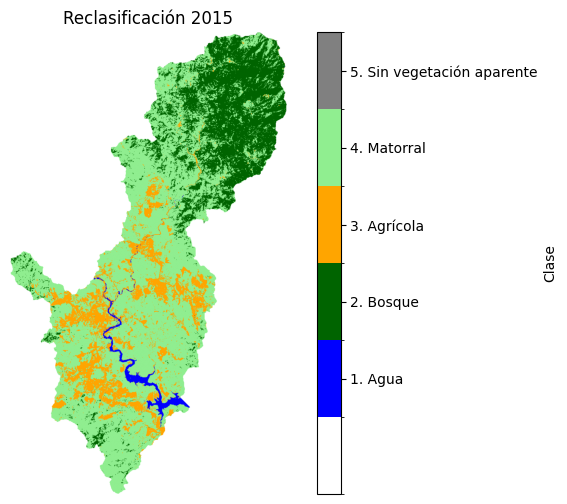

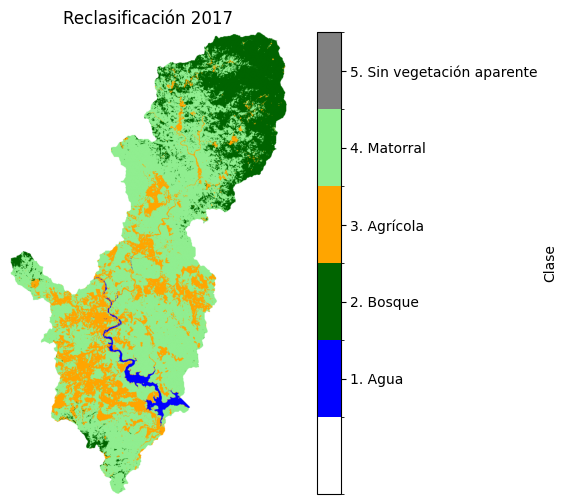

In [ ]:
# @title
ruta_raster_1 = '/content/drive/MyDrive/EarthEngine/reclas_zona2_2015_X.tif'
ruta_raster_2 = '/content/drive/MyDrive/EarthEngine/reclas_zona2_2017_X.tif'

nombre_raster_1 = '2015'
nombre_raster_2 = '2017'
zona = 'zona - 2'

periodo_anios = 2

carpeta_salida = '/content/drive/MyDrive/Analisis_cambio_uso_suelo'
os.makedirs(carpeta_salida, exist_ok=True)

salida_excel = os.path.join(
    carpeta_salida,
    f'analisis_cambio_uso_suelo_{nombre_raster_1}_{nombre_raster_2}_{zona}.xlsx'
)

def read_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1)
        nodata = src.nodata
        transform = src.transform
        crs = src.crs
        shape = data.shape
    return data, nodata, transform, crs, shape

raster_1, nodata_1, transform_1, crs_1, shape_1 = read_raster(ruta_raster_1)
raster_2, nodata_2, transform_2, crs_2, shape_2 = read_raster(ruta_raster_2)

if shape_1 != shape_2:
    raise ValueError("Los raster no tienen el mismo tamaño.")

if transform_1 != transform_2:
    print("Advertencia: los raster tienen diferente alineación espacial o resolución.")

if crs_1 != crs_2:
    print("Advertencia: los raster tienen diferente sistema de coordenadas.")


flat_1 = raster_1.flatten()
flat_2 = raster_2.flatten()

mask = (flat_1 > 0) & (flat_2 > 0)

if nodata_1 is not None:
    mask = mask & (flat_1 != nodata_1)

if nodata_2 is not None:
    mask = mask & (flat_2 != nodata_2)

flat_1 = flat_1[mask]
flat_2 = flat_2[mask]

clases = np.unique(np.concatenate((flat_1, flat_2)))
clases.sort()

n = len(clases)
clase_dict = {v: i for i, v in enumerate(clases)}

matriz = np.zeros((n, n), dtype=int)

for c1, c2 in zip(flat_1, flat_2):
    i = clase_dict[c1]
    j = clase_dict[c2]
    matriz[i, j] += 1

df_matriz_pixeles = pd.DataFrame(
    matriz,
    index=[f'Clase {int(c)}' for c in clases],
    columns=[f'Clase {int(c)}' for c in clases]
)

pixel_area_ha = 30 * 30 / 10000
matriz_ha = matriz * pixel_area_ha

df_matriz_ha = pd.DataFrame(
    matriz_ha,
    index=[f'Clase {int(c)}' for c in clases],
    columns=[f'Clase {int(c)}' for c in clases]
)

resultados = []

for i, clase in enumerate(clases):
    fila = matriz[i, :]
    col = matriz[:, i]

    inicial = fila.sum()
    final = col.sum()
    persistencia = matriz[i, i]
    perdida = inicial - persistencia
    ganancia = final - persistencia
    cambio_neto = ganancia - perdida
    cambio_total = ganancia + perdida

    porcentaje_cambio = cambio_total / inicial * 100 if inicial > 0 else 0
    tasa_anual = porcentaje_cambio / periodo_anios if periodo_anios > 0 else 0

    resultados.append({
        'Clase': int(clase),
        'Área Inicial (ha)': inicial * pixel_area_ha,
        'Área Final (ha)': final * pixel_area_ha,
        'Persistencia (ha)': persistencia * pixel_area_ha,
        'Pérdida (ha)': perdida * pixel_area_ha,
        'Ganancia (ha)': ganancia * pixel_area_ha,
        'Cambio Neto (ha)': cambio_neto * pixel_area_ha,
        'Cambio Total (ha)': cambio_total * pixel_area_ha,
        '% de Cambio': porcentaje_cambio,
        'Tasa Anual (%)': tasa_anual
    })

df_resultados = pd.DataFrame(resultados).set_index('Clase')

print(f"\n MATRIZ DE TRANSICIÓN {nombre_raster_1}–{nombre_raster_2} (pixeles):")
display(df_matriz_pixeles)

print(f"\n MATRIZ DE TRANSICIÓN {nombre_raster_1}–{nombre_raster_2} (ha):")
display(df_matriz_ha.round(2))

print(f"\n TABLA RESUMEN DE CAMBIOS {nombre_raster_1}–{nombre_raster_2}:")
display(df_resultados.round(2))

with pd.ExcelWriter(salida_excel, engine='openpyxl') as writer:
    df_matriz_pixeles.to_excel(writer, sheet_name='Matriz_transicion_pixeles')
    df_matriz_ha.round(4).to_excel(writer, sheet_name='Matriz_transicion_ha')
    df_resultados.round(4).to_excel(writer, sheet_name='Resumen_cambios')

print("Archivo Excel exportado correctamente en:")
print(salida_excel)

colores = [
    'white',
    'blue',
    'darkgreen',
    'orange',
    'lightgreen',
    'gray'
]

etiquetas = [
    '1. Agua',
    '2. Bosque',
    '3. Agrícola',
    '4. Matorral',
    '5. Sin vegetación aparente'
]

cmap = ListedColormap(colores)
boundaries = np.arange(0, 7) - 0.5
norm = BoundaryNorm(boundaries, cmap.N)

def plot_classification_colored(data, title):
    plt.figure(figsize=(8, 6))
    im = plt.imshow(data, cmap=cmap, norm=norm)
    cbar = plt.colorbar(im, ticks=np.arange(1, 6))
    cbar.set_label('Clase')
    cbar.ax.set_yticklabels(etiquetas)
    plt.title(title)
    plt.axis('off')
    plt.show()

plot_classification_colored(raster_1, f'Reclasificación {nombre_raster_1}')
plot_classification_colored(raster_2, f'Reclasificación {nombre_raster_2}')

#Analisis de cambio de uso de suelo ZONA 3 2013-2015


 MATRIZ DE TRANSICIÓN 2013–2015 (pixeles):


,Clase 1,Clase 2,Clase 3,Clase 4,Clase 5
Clase 1,1723,0,0,0,0
Clase 2,3,98,0,173,0
Clase 3,596,1,2636,1120,3
Clase 4,250,861,2244,31274,0
Clase 5,3087,0,120,159,9



 MATRIZ DE TRANSICIÓN 2013–2015 (ha):


,Clase 1,Clase 2,Clase 3,Clase 4,Clase 5
Clase 1,155.07,0.00,0.00,0.00,0.00
Clase 2,0.27,8.82,0.00,15.57,0.00
Clase 3,53.64,0.09,237.24,100.80,0.27
Clase 4,22.50,77.49,201.96,2814.66,0.00
Clase 5,277.83,0.00,10.80,14.31,0.81



 TABLA RESUMEN DE CAMBIOS 2013–2015:


,Área Inicial (ha),Área Final (ha),Persistencia (ha),Pérdida (ha),Ganancia (ha),Cambio Neto (ha),Cambio Total (ha),% de Cambio,Tasa Anual (%)
Clase,,,,,,,,,
1,155.07,509.31,155.07,0.00,354.24,354.24,354.24,228.44,114.22
2,24.66,86.40,8.82,15.84,77.58,61.74,93.42,378.83,189.42
3,392.04,450.00,237.24,154.80,212.76,57.96,367.56,93.76,46.88
4,3116.61,2945.34,2814.66,301.95,130.68,-171.27,432.63,13.88,6.94
5,303.75,1.08,0.81,302.94,0.27,-302.67,303.21,99.82,49.91


Archivo Excel exportado correctamente en:
/content/drive/MyDrive/Analisis_cambio_uso_suelo/analisis_cambio_uso_suelo_2013_2015_zona - 3.xlsx


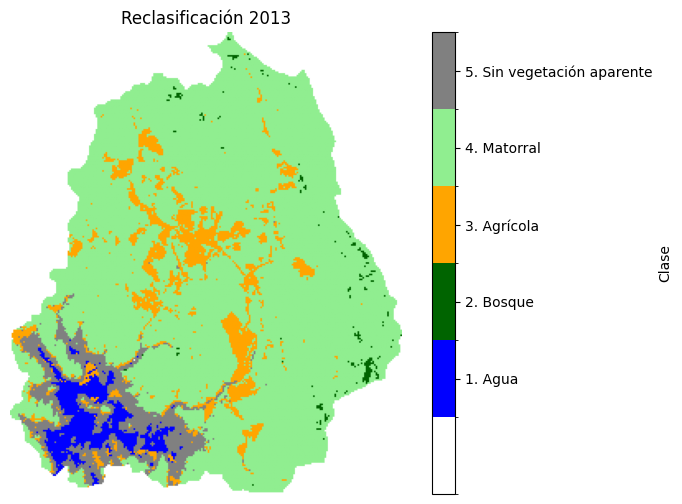

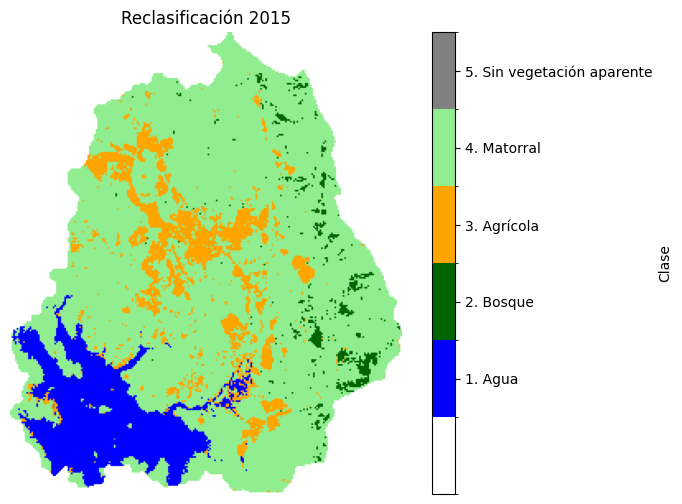

In [ ]:
# @title
ruta_raster_1 = '/content/drive/MyDrive/EarthEngine/reclas_zona3_2013_X.tif'
ruta_raster_2 = '/content/drive/MyDrive/EarthEngine/reclas_zona3_2015_X.tif'

nombre_raster_1 = '2013'
nombre_raster_2 = '2015'
zona = 'zona - 3'

periodo_anios = 2

carpeta_salida = '/content/drive/MyDrive/Analisis_cambio_uso_suelo'
os.makedirs(carpeta_salida, exist_ok=True)

salida_excel = os.path.join(
    carpeta_salida,
    f'analisis_cambio_uso_suelo_{nombre_raster_1}_{nombre_raster_2}_{zona}.xlsx'
)

def read_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1)
        nodata = src.nodata
        transform = src.transform
        crs = src.crs
        shape = data.shape
    return data, nodata, transform, crs, shape

raster_1, nodata_1, transform_1, crs_1, shape_1 = read_raster(ruta_raster_1)
raster_2, nodata_2, transform_2, crs_2, shape_2 = read_raster(ruta_raster_2)

if shape_1 != shape_2:
    raise ValueError("Los raster no tienen el mismo tamaño.")

if transform_1 != transform_2:
    print("Advertencia: los raster tienen diferente alineación espacial o resolución.")

if crs_1 != crs_2:
    print("Advertencia: los raster tienen diferente sistema de coordenadas.")


flat_1 = raster_1.flatten()
flat_2 = raster_2.flatten()

mask = (flat_1 > 0) & (flat_2 > 0)

if nodata_1 is not None:
    mask = mask & (flat_1 != nodata_1)

if nodata_2 is not None:
    mask = mask & (flat_2 != nodata_2)

flat_1 = flat_1[mask]
flat_2 = flat_2[mask]

clases = np.unique(np.concatenate((flat_1, flat_2)))
clases.sort()

n = len(clases)
clase_dict = {v: i for i, v in enumerate(clases)}

matriz = np.zeros((n, n), dtype=int)

for c1, c2 in zip(flat_1, flat_2):
    i = clase_dict[c1]
    j = clase_dict[c2]
    matriz[i, j] += 1

df_matriz_pixeles = pd.DataFrame(
    matriz,
    index=[f'Clase {int(c)}' for c in clases],
    columns=[f'Clase {int(c)}' for c in clases]
)

pixel_area_ha = 30 * 30 / 10000
matriz_ha = matriz * pixel_area_ha

df_matriz_ha = pd.DataFrame(
    matriz_ha,
    index=[f'Clase {int(c)}' for c in clases],
    columns=[f'Clase {int(c)}' for c in clases]
)

resultados = []

for i, clase in enumerate(clases):
    fila = matriz[i, :]
    col = matriz[:, i]

    inicial = fila.sum()
    final = col.sum()
    persistencia = matriz[i, i]
    perdida = inicial - persistencia
    ganancia = final - persistencia
    cambio_neto = ganancia - perdida
    cambio_total = ganancia + perdida

    porcentaje_cambio = cambio_total / inicial * 100 if inicial > 0 else 0
    tasa_anual = porcentaje_cambio / periodo_anios if periodo_anios > 0 else 0

    resultados.append({
        'Clase': int(clase),
        'Área Inicial (ha)': inicial * pixel_area_ha,
        'Área Final (ha)': final * pixel_area_ha,
        'Persistencia (ha)': persistencia * pixel_area_ha,
        'Pérdida (ha)': perdida * pixel_area_ha,
        'Ganancia (ha)': ganancia * pixel_area_ha,
        'Cambio Neto (ha)': cambio_neto * pixel_area_ha,
        'Cambio Total (ha)': cambio_total * pixel_area_ha,
        '% de Cambio': porcentaje_cambio,
        'Tasa Anual (%)': tasa_anual
    })

df_resultados = pd.DataFrame(resultados).set_index('Clase')

print(f"\n MATRIZ DE TRANSICIÓN {nombre_raster_1}–{nombre_raster_2} (pixeles):")
display(df_matriz_pixeles)

print(f"\n MATRIZ DE TRANSICIÓN {nombre_raster_1}–{nombre_raster_2} (ha):")
display(df_matriz_ha.round(2))

print(f"\n TABLA RESUMEN DE CAMBIOS {nombre_raster_1}–{nombre_raster_2}:")
display(df_resultados.round(2))

with pd.ExcelWriter(salida_excel, engine='openpyxl') as writer:
    df_matriz_pixeles.to_excel(writer, sheet_name='Matriz_transicion_pixeles')
    df_matriz_ha.round(4).to_excel(writer, sheet_name='Matriz_transicion_ha')
    df_resultados.round(4).to_excel(writer, sheet_name='Resumen_cambios')

print("Archivo Excel exportado correctamente en:")
print(salida_excel)

colores = [
    'white',
    'blue',
    'darkgreen',
    'orange',
    'lightgreen',
    'gray'
]

etiquetas = [
    '1. Agua',
    '2. Bosque',
    '3. Agrícola',
    '4. Matorral',
    '5. Sin vegetación aparente'
]

cmap = ListedColormap(colores)
boundaries = np.arange(0, 7) - 0.5
norm = BoundaryNorm(boundaries, cmap.N)

def plot_classification_colored(data, title):
    plt.figure(figsize=(8, 6))
    im = plt.imshow(data, cmap=cmap, norm=norm)
    cbar = plt.colorbar(im, ticks=np.arange(1, 6))
    cbar.set_label('Clase')
    cbar.ax.set_yticklabels(etiquetas)
    plt.title(title)
    plt.axis('off')
    plt.show()

plot_classification_colored(raster_1, f'Reclasificación {nombre_raster_1}')
plot_classification_colored(raster_2, f'Reclasificación {nombre_raster_2}')

#Analisis de cambio de uso de suelo ZONA 3 2015-2017


 MATRIZ DE TRANSICIÓN 2015–2017 (pixeles):


,Clase 1,Clase 2,Clase 3,Clase 4,Clase 5
Clase 1,5309,0,215,94,42
Clase 2,1,344,3,612,0
Clase 3,87,4,3417,1477,15
Clase 4,725,1156,1495,29350,0
Clase 5,2,0,7,2,1



 MATRIZ DE TRANSICIÓN 2015–2017 (ha):


,Clase 1,Clase 2,Clase 3,Clase 4,Clase 5
Clase 1,477.81,0.00,19.35,8.46,3.78
Clase 2,0.09,30.96,0.27,55.08,0.00
Clase 3,7.83,0.36,307.53,132.93,1.35
Clase 4,65.25,104.04,134.55,2641.50,0.00
Clase 5,0.18,0.00,0.63,0.18,0.09



 TABLA RESUMEN DE CAMBIOS 2015–2017:


,Área Inicial (ha),Área Final (ha),Persistencia (ha),Pérdida (ha),Ganancia (ha),Cambio Neto (ha),Cambio Total (ha),% de Cambio,Tasa Anual (%)
Clase,,,,,,,,,
1,509.40,551.16,477.81,31.59,73.35,41.76,104.94,20.60,10.30
2,86.40,135.36,30.96,55.44,104.40,48.96,159.84,185.00,92.50
3,450.00,462.33,307.53,142.47,154.80,12.33,297.27,66.06,33.03
4,2945.34,2838.15,2641.50,303.84,196.65,-107.19,500.49,16.99,8.50
5,1.08,5.22,0.09,0.99,5.13,4.14,6.12,566.67,283.33


Archivo Excel exportado correctamente en:
/content/drive/MyDrive/Analisis_cambio_uso_suelo/analisis_cambio_uso_suelo_2015_2017_zona - 3.xlsx


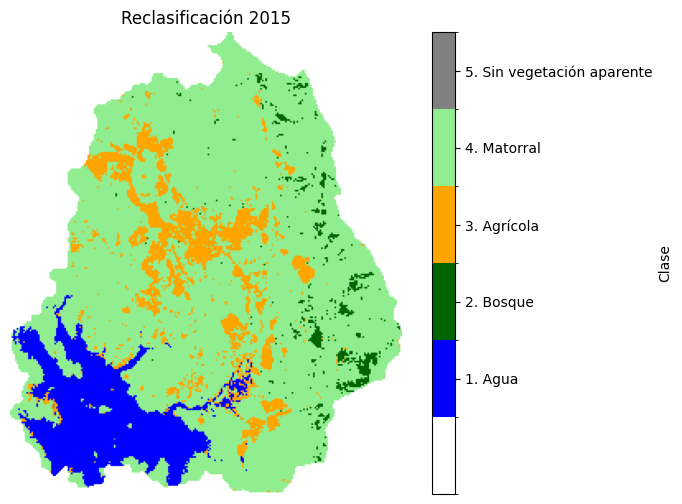

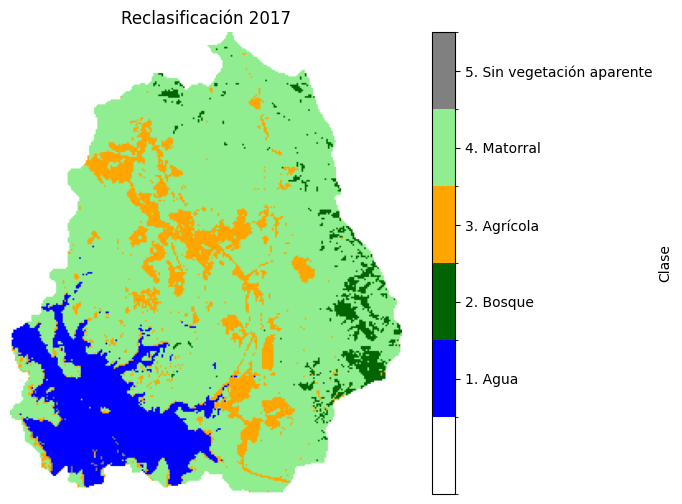

In [ ]:
# @title
ruta_raster_1 = '/content/drive/MyDrive/EarthEngine/reclas_zona3_2015_X.tif'
ruta_raster_2 = '/content/drive/MyDrive/EarthEngine/reclas_zona3_2017_X.tif'

nombre_raster_1 = '2015'
nombre_raster_2 = '2017'
zona = 'zona - 3'

periodo_anios = 2

carpeta_salida = '/content/drive/MyDrive/Analisis_cambio_uso_suelo'
os.makedirs(carpeta_salida, exist_ok=True)

salida_excel = os.path.join(
    carpeta_salida,
    f'analisis_cambio_uso_suelo_{nombre_raster_1}_{nombre_raster_2}_{zona}.xlsx'
)

def read_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1)
        nodata = src.nodata
        transform = src.transform
        crs = src.crs
        shape = data.shape
    return data, nodata, transform, crs, shape

raster_1, nodata_1, transform_1, crs_1, shape_1 = read_raster(ruta_raster_1)
raster_2, nodata_2, transform_2, crs_2, shape_2 = read_raster(ruta_raster_2)

if shape_1 != shape_2:
    raise ValueError("Los raster no tienen el mismo tamaño.")

if transform_1 != transform_2:
    print("Advertencia: los raster tienen diferente alineación espacial o resolución.")

if crs_1 != crs_2:
    print("Advertencia: los raster tienen diferente sistema de coordenadas.")


flat_1 = raster_1.flatten()
flat_2 = raster_2.flatten()

mask = (flat_1 > 0) & (flat_2 > 0)

if nodata_1 is not None:
    mask = mask & (flat_1 != nodata_1)

if nodata_2 is not None:
    mask = mask & (flat_2 != nodata_2)

flat_1 = flat_1[mask]
flat_2 = flat_2[mask]

clases = np.unique(np.concatenate((flat_1, flat_2)))
clases.sort()

n = len(clases)
clase_dict = {v: i for i, v in enumerate(clases)}

matriz = np.zeros((n, n), dtype=int)

for c1, c2 in zip(flat_1, flat_2):
    i = clase_dict[c1]
    j = clase_dict[c2]
    matriz[i, j] += 1

df_matriz_pixeles = pd.DataFrame(
    matriz,
    index=[f'Clase {int(c)}' for c in clases],
    columns=[f'Clase {int(c)}' for c in clases]
)

pixel_area_ha = 30 * 30 / 10000
matriz_ha = matriz * pixel_area_ha

df_matriz_ha = pd.DataFrame(
    matriz_ha,
    index=[f'Clase {int(c)}' for c in clases],
    columns=[f'Clase {int(c)}' for c in clases]
)

resultados = []

for i, clase in enumerate(clases):
    fila = matriz[i, :]
    col = matriz[:, i]

    inicial = fila.sum()
    final = col.sum()
    persistencia = matriz[i, i]
    perdida = inicial - persistencia
    ganancia = final - persistencia
    cambio_neto = ganancia - perdida
    cambio_total = ganancia + perdida

    porcentaje_cambio = cambio_total / inicial * 100 if inicial > 0 else 0
    tasa_anual = porcentaje_cambio / periodo_anios if periodo_anios > 0 else 0

    resultados.append({
        'Clase': int(clase),
        'Área Inicial (ha)': inicial * pixel_area_ha,
        'Área Final (ha)': final * pixel_area_ha,
        'Persistencia (ha)': persistencia * pixel_area_ha,
        'Pérdida (ha)': perdida * pixel_area_ha,
        'Ganancia (ha)': ganancia * pixel_area_ha,
        'Cambio Neto (ha)': cambio_neto * pixel_area_ha,
        'Cambio Total (ha)': cambio_total * pixel_area_ha,
        '% de Cambio': porcentaje_cambio,
        'Tasa Anual (%)': tasa_anual
    })

df_resultados = pd.DataFrame(resultados).set_index('Clase')

print(f"\n MATRIZ DE TRANSICIÓN {nombre_raster_1}–{nombre_raster_2} (pixeles):")
display(df_matriz_pixeles)

print(f"\n MATRIZ DE TRANSICIÓN {nombre_raster_1}–{nombre_raster_2} (ha):")
display(df_matriz_ha.round(2))

print(f"\n TABLA RESUMEN DE CAMBIOS {nombre_raster_1}–{nombre_raster_2}:")
display(df_resultados.round(2))

with pd.ExcelWriter(salida_excel, engine='openpyxl') as writer:
    df_matriz_pixeles.to_excel(writer, sheet_name='Matriz_transicion_pixeles')
    df_matriz_ha.round(4).to_excel(writer, sheet_name='Matriz_transicion_ha')
    df_resultados.round(4).to_excel(writer, sheet_name='Resumen_cambios')

print("Archivo Excel exportado correctamente en:")
print(salida_excel)

colores = [
    'white',
    'blue',
    'darkgreen',
    'orange',
    'lightgreen',
    'gray'
]

etiquetas = [
    '1. Agua',
    '2. Bosque',
    '3. Agrícola',
    '4. Matorral',
    '5. Sin vegetación aparente'
]

cmap = ListedColormap(colores)
boundaries = np.arange(0, 7) - 0.5
norm = BoundaryNorm(boundaries, cmap.N)

def plot_classification_colored(data, title):
    plt.figure(figsize=(8, 6))
    im = plt.imshow(data, cmap=cmap, norm=norm)
    cbar = plt.colorbar(im, ticks=np.arange(1, 6))
    cbar.set_label('Clase')
    cbar.ax.set_yticklabels(etiquetas)
    plt.title(title)
    plt.axis('off')
    plt.show()

plot_classification_colored(raster_1, f'Reclasificación {nombre_raster_1}')
plot_classification_colored(raster_2, f'Reclasificación {nombre_raster_2}')

#Analisis de cambio de uso de suelo ZONA 4 2013-2015


 MATRIZ DE TRANSICIÓN 2013–2015 (pixeles):


,Clase 1,Clase 2,Clase 3,Clase 4,Clase 5
Clase 1,5644,0,1,0,0
Clase 2,1,1377,0,1262,0
Clase 3,562,11,1272,709,8
Clase 4,629,10311,1455,84134,6
Clase 5,6378,4,290,238,31



 MATRIZ DE TRANSICIÓN 2013–2015 (ha):


,Clase 1,Clase 2,Clase 3,Clase 4,Clase 5
Clase 1,507.96,0.00,0.09,0.00,0.00
Clase 2,0.09,123.93,0.00,113.58,0.00
Clase 3,50.58,0.99,114.48,63.81,0.72
Clase 4,56.61,927.99,130.95,7572.06,0.54
Clase 5,574.02,0.36,26.10,21.42,2.79



 TABLA RESUMEN DE CAMBIOS 2013–2015:


,Área Inicial (ha),Área Final (ha),Persistencia (ha),Pérdida (ha),Ganancia (ha),Cambio Neto (ha),Cambio Total (ha),% de Cambio,Tasa Anual (%)
Clase,,,,,,,,,
1,508.05,1189.26,507.96,0.09,681.30,681.21,681.39,134.12,67.06
2,237.60,1053.27,123.93,113.67,929.34,815.67,1043.01,438.98,219.49
3,230.58,271.62,114.48,116.10,157.14,41.04,273.24,118.50,59.25
4,8688.15,7770.87,7572.06,1116.09,198.81,-917.28,1314.90,15.13,7.57
5,624.69,4.05,2.79,621.90,1.26,-620.64,623.16,99.76,49.88


Archivo Excel exportado correctamente en:
/content/drive/MyDrive/Analisis_cambio_uso_suelo/analisis_cambio_uso_suelo_2013_2015_zona - 4.xlsx


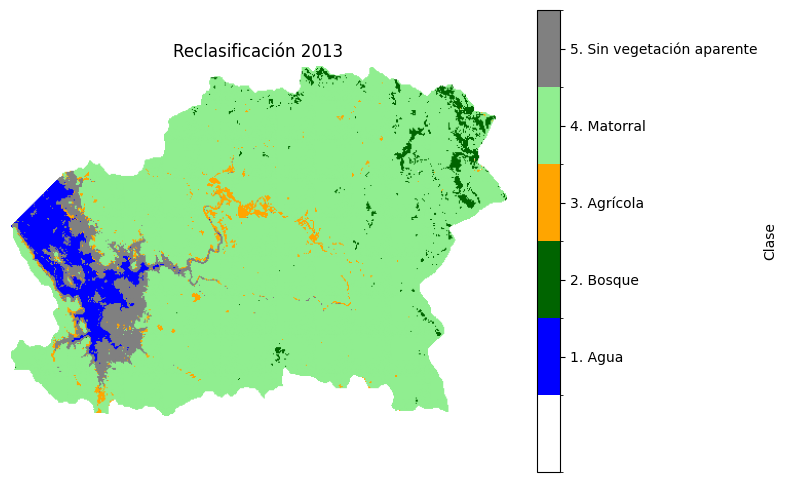

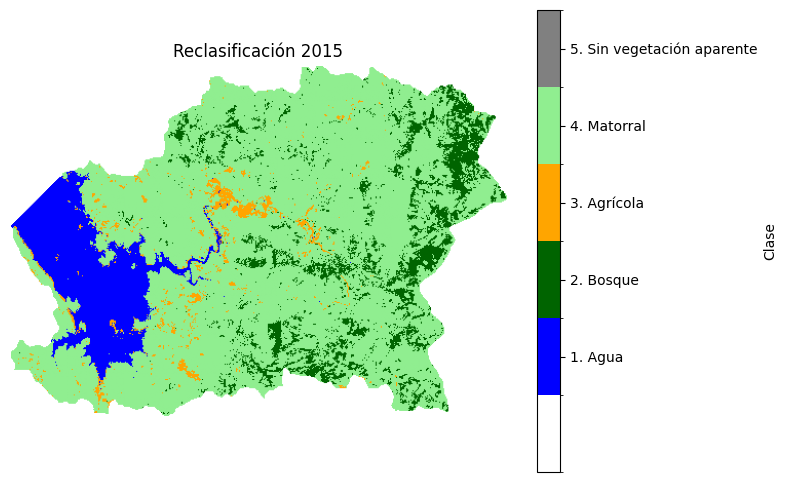

In [ ]:
# @title
ruta_raster_1 = '/content/drive/MyDrive/EarthEngine/reclas_zona4_2013_X.tif'
ruta_raster_2 = '/content/drive/MyDrive/EarthEngine/reclas_zona4_2015_X.tif'

nombre_raster_1 = '2013'
nombre_raster_2 = '2015'
zona = 'zona - 4'

periodo_anios = 2

carpeta_salida = '/content/drive/MyDrive/Analisis_cambio_uso_suelo'
os.makedirs(carpeta_salida, exist_ok=True)

salida_excel = os.path.join(
    carpeta_salida,
    f'analisis_cambio_uso_suelo_{nombre_raster_1}_{nombre_raster_2}_{zona}.xlsx'
)

def read_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1)
        nodata = src.nodata
        transform = src.transform
        crs = src.crs
        shape = data.shape
    return data, nodata, transform, crs, shape

raster_1, nodata_1, transform_1, crs_1, shape_1 = read_raster(ruta_raster_1)
raster_2, nodata_2, transform_2, crs_2, shape_2 = read_raster(ruta_raster_2)

if shape_1 != shape_2:
    raise ValueError("Los raster no tienen el mismo tamaño.")

if transform_1 != transform_2:
    print("Advertencia: los raster tienen diferente alineación espacial o resolución.")

if crs_1 != crs_2:
    print("Advertencia: los raster tienen diferente sistema de coordenadas.")


flat_1 = raster_1.flatten()
flat_2 = raster_2.flatten()

mask = (flat_1 > 0) & (flat_2 > 0)

if nodata_1 is not None:
    mask = mask & (flat_1 != nodata_1)

if nodata_2 is not None:
    mask = mask & (flat_2 != nodata_2)

flat_1 = flat_1[mask]
flat_2 = flat_2[mask]

clases = np.unique(np.concatenate((flat_1, flat_2)))
clases.sort()

n = len(clases)
clase_dict = {v: i for i, v in enumerate(clases)}

matriz = np.zeros((n, n), dtype=int)

for c1, c2 in zip(flat_1, flat_2):
    i = clase_dict[c1]
    j = clase_dict[c2]
    matriz[i, j] += 1

df_matriz_pixeles = pd.DataFrame(
    matriz,
    index=[f'Clase {int(c)}' for c in clases],
    columns=[f'Clase {int(c)}' for c in clases]
)

pixel_area_ha = 30 * 30 / 10000
matriz_ha = matriz * pixel_area_ha

df_matriz_ha = pd.DataFrame(
    matriz_ha,
    index=[f'Clase {int(c)}' for c in clases],
    columns=[f'Clase {int(c)}' for c in clases]
)

resultados = []

for i, clase in enumerate(clases):
    fila = matriz[i, :]
    col = matriz[:, i]

    inicial = fila.sum()
    final = col.sum()
    persistencia = matriz[i, i]
    perdida = inicial - persistencia
    ganancia = final - persistencia
    cambio_neto = ganancia - perdida
    cambio_total = ganancia + perdida

    porcentaje_cambio = cambio_total / inicial * 100 if inicial > 0 else 0
    tasa_anual = porcentaje_cambio / periodo_anios if periodo_anios > 0 else 0

    resultados.append({
        'Clase': int(clase),
        'Área Inicial (ha)': inicial * pixel_area_ha,
        'Área Final (ha)': final * pixel_area_ha,
        'Persistencia (ha)': persistencia * pixel_area_ha,
        'Pérdida (ha)': perdida * pixel_area_ha,
        'Ganancia (ha)': ganancia * pixel_area_ha,
        'Cambio Neto (ha)': cambio_neto * pixel_area_ha,
        'Cambio Total (ha)': cambio_total * pixel_area_ha,
        '% de Cambio': porcentaje_cambio,
        'Tasa Anual (%)': tasa_anual
    })

df_resultados = pd.DataFrame(resultados).set_index('Clase')

print(f"\n MATRIZ DE TRANSICIÓN {nombre_raster_1}–{nombre_raster_2} (pixeles):")
display(df_matriz_pixeles)

print(f"\n MATRIZ DE TRANSICIÓN {nombre_raster_1}–{nombre_raster_2} (ha):")
display(df_matriz_ha.round(2))

print(f"\n TABLA RESUMEN DE CAMBIOS {nombre_raster_1}–{nombre_raster_2}:")
display(df_resultados.round(2))

with pd.ExcelWriter(salida_excel, engine='openpyxl') as writer:
    df_matriz_pixeles.to_excel(writer, sheet_name='Matriz_transicion_pixeles')
    df_matriz_ha.round(4).to_excel(writer, sheet_name='Matriz_transicion_ha')
    df_resultados.round(4).to_excel(writer, sheet_name='Resumen_cambios')

print("Archivo Excel exportado correctamente en:")
print(salida_excel)

colores = [
    'white',
    'blue',
    'darkgreen',
    'orange',
    'lightgreen',
    'gray'
]

etiquetas = [
    '1. Agua',
    '2. Bosque',
    '3. Agrícola',
    '4. Matorral',
    '5. Sin vegetación aparente'
]

cmap = ListedColormap(colores)
boundaries = np.arange(0, 7) - 0.5
norm = BoundaryNorm(boundaries, cmap.N)

def plot_classification_colored(data, title):
    plt.figure(figsize=(8, 6))
    im = plt.imshow(data, cmap=cmap, norm=norm)
    cbar = plt.colorbar(im, ticks=np.arange(1, 6))
    cbar.set_label('Clase')
    cbar.ax.set_yticklabels(etiquetas)
    plt.title(title)
    plt.axis('off')
    plt.show()

plot_classification_colored(raster_1, f'Reclasificación {nombre_raster_1}')
plot_classification_colored(raster_2, f'Reclasificación {nombre_raster_2}')

#Analisis de cambio de uso de suelo ZONA 4 2015-2017


 MATRIZ DE TRANSICIÓN 2015–2017 (pixeles):


,Clase 1,Clase 2,Clase 3,Clase 4,Clase 5
Clase 1,12809,0,288,61,56
Clase 2,7,5252,138,6308,0
Clase 3,233,7,1747,975,56
Clase 4,992,8319,3787,73245,1
Clase 5,20,0,19,1,5



 MATRIZ DE TRANSICIÓN 2015–2017 (ha):


,Clase 1,Clase 2,Clase 3,Clase 4,Clase 5
Clase 1,1152.81,0.00,25.92,5.49,5.04
Clase 2,0.63,472.68,12.42,567.72,0.00
Clase 3,20.97,0.63,157.23,87.75,5.04
Clase 4,89.28,748.71,340.83,6592.05,0.09
Clase 5,1.80,0.00,1.71,0.09,0.45



 TABLA RESUMEN DE CAMBIOS 2015–2017:


,Área Inicial (ha),Área Final (ha),Persistencia (ha),Pérdida (ha),Ganancia (ha),Cambio Neto (ha),Cambio Total (ha),% de Cambio,Tasa Anual (%)
Clase,,,,,,,,,
1,1189.26,1265.49,1152.81,36.45,112.68,76.23,149.13,12.54,6.27
2,1053.45,1222.02,472.68,580.77,749.34,168.57,1330.11,126.26,63.13
3,271.62,538.11,157.23,114.39,380.88,266.49,495.27,182.34,91.17
4,7770.96,7253.10,6592.05,1178.91,661.05,-517.86,1839.96,23.68,11.84
5,4.05,10.62,0.45,3.60,10.17,6.57,13.77,340.00,170.00


Archivo Excel exportado correctamente en:
/content/drive/MyDrive/Analisis_cambio_uso_suelo/analisis_cambio_uso_suelo_2015_2017_zona - 4.xlsx


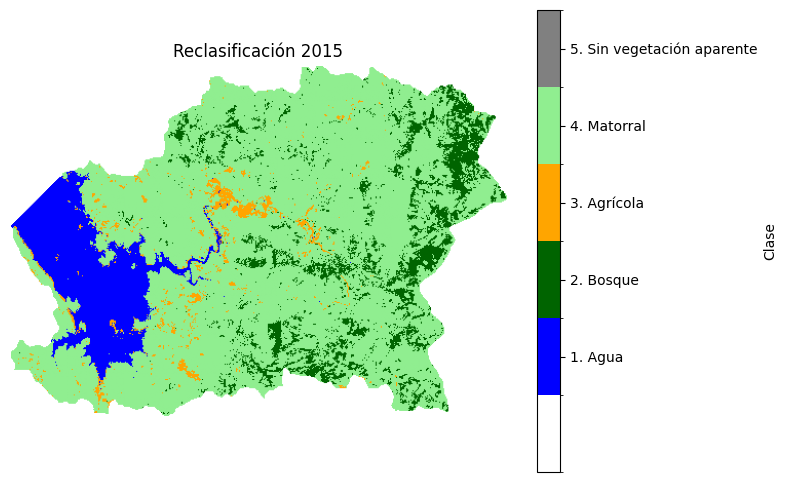

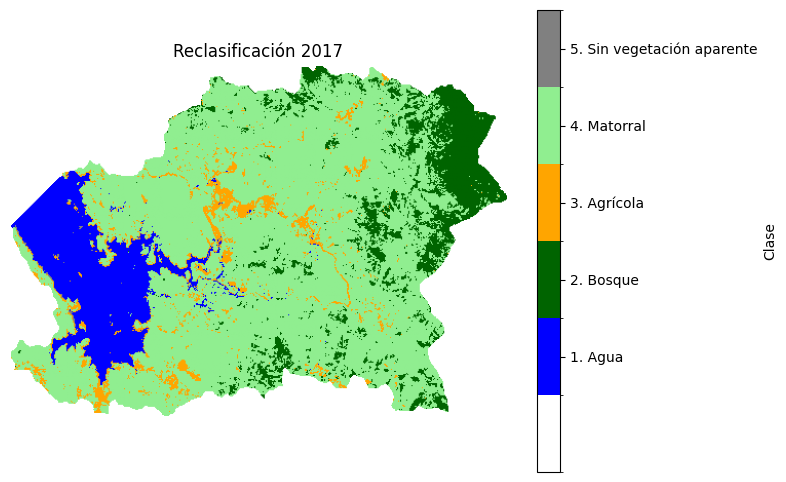

In [ ]:
# @title
ruta_raster_1 = '/content/drive/MyDrive/EarthEngine/reclas_zona4_2015_X.tif'
ruta_raster_2 = '/content/drive/MyDrive/EarthEngine/reclas_zona4_2017_X.tif'

nombre_raster_1 = '2015'
nombre_raster_2 = '2017'
zona = 'zona - 4'

periodo_anios = 2

carpeta_salida = '/content/drive/MyDrive/Analisis_cambio_uso_suelo'
os.makedirs(carpeta_salida, exist_ok=True)

salida_excel = os.path.join(
    carpeta_salida,
    f'analisis_cambio_uso_suelo_{nombre_raster_1}_{nombre_raster_2}_{zona}.xlsx'
)

def read_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1)
        nodata = src.nodata
        transform = src.transform
        crs = src.crs
        shape = data.shape
    return data, nodata, transform, crs, shape

raster_1, nodata_1, transform_1, crs_1, shape_1 = read_raster(ruta_raster_1)
raster_2, nodata_2, transform_2, crs_2, shape_2 = read_raster(ruta_raster_2)

if shape_1 != shape_2:
    raise ValueError("Los raster no tienen el mismo tamaño.")

if transform_1 != transform_2:
    print("Advertencia: los raster tienen diferente alineación espacial o resolución.")

if crs_1 != crs_2:
    print("Advertencia: los raster tienen diferente sistema de coordenadas.")


flat_1 = raster_1.flatten()
flat_2 = raster_2.flatten()

mask = (flat_1 > 0) & (flat_2 > 0)

if nodata_1 is not None:
    mask = mask & (flat_1 != nodata_1)

if nodata_2 is not None:
    mask = mask & (flat_2 != nodata_2)

flat_1 = flat_1[mask]
flat_2 = flat_2[mask]

clases = np.unique(np.concatenate((flat_1, flat_2)))
clases.sort()

n = len(clases)
clase_dict = {v: i for i, v in enumerate(clases)}

matriz = np.zeros((n, n), dtype=int)

for c1, c2 in zip(flat_1, flat_2):
    i = clase_dict[c1]
    j = clase_dict[c2]
    matriz[i, j] += 1

df_matriz_pixeles = pd.DataFrame(
    matriz,
    index=[f'Clase {int(c)}' for c in clases],
    columns=[f'Clase {int(c)}' for c in clases]
)

pixel_area_ha = 30 * 30 / 10000
matriz_ha = matriz * pixel_area_ha

df_matriz_ha = pd.DataFrame(
    matriz_ha,
    index=[f'Clase {int(c)}' for c in clases],
    columns=[f'Clase {int(c)}' for c in clases]
)

resultados = []

for i, clase in enumerate(clases):
    fila = matriz[i, :]
    col = matriz[:, i]

    inicial = fila.sum()
    final = col.sum()
    persistencia = matriz[i, i]
    perdida = inicial - persistencia
    ganancia = final - persistencia
    cambio_neto = ganancia - perdida
    cambio_total = ganancia + perdida

    porcentaje_cambio = cambio_total / inicial * 100 if inicial > 0 else 0
    tasa_anual = porcentaje_cambio / periodo_anios if periodo_anios > 0 else 0

    resultados.append({
        'Clase': int(clase),
        'Área Inicial (ha)': inicial * pixel_area_ha,
        'Área Final (ha)': final * pixel_area_ha,
        'Persistencia (ha)': persistencia * pixel_area_ha,
        'Pérdida (ha)': perdida * pixel_area_ha,
        'Ganancia (ha)': ganancia * pixel_area_ha,
        'Cambio Neto (ha)': cambio_neto * pixel_area_ha,
        'Cambio Total (ha)': cambio_total * pixel_area_ha,
        '% de Cambio': porcentaje_cambio,
        'Tasa Anual (%)': tasa_anual
    })

df_resultados = pd.DataFrame(resultados).set_index('Clase')

print(f"\n MATRIZ DE TRANSICIÓN {nombre_raster_1}–{nombre_raster_2} (pixeles):")
display(df_matriz_pixeles)

print(f"\n MATRIZ DE TRANSICIÓN {nombre_raster_1}–{nombre_raster_2} (ha):")
display(df_matriz_ha.round(2))

print(f"\n TABLA RESUMEN DE CAMBIOS {nombre_raster_1}–{nombre_raster_2}:")
display(df_resultados.round(2))

with pd.ExcelWriter(salida_excel, engine='openpyxl') as writer:
    df_matriz_pixeles.to_excel(writer, sheet_name='Matriz_transicion_pixeles')
    df_matriz_ha.round(4).to_excel(writer, sheet_name='Matriz_transicion_ha')
    df_resultados.round(4).to_excel(writer, sheet_name='Resumen_cambios')

print("Archivo Excel exportado correctamente en:")
print(salida_excel)

colores = [
    'white',
    'blue',
    'darkgreen',
    'orange',
    'lightgreen',
    'gray'
]

etiquetas = [
    '1. Agua',
    '2. Bosque',
    '3. Agrícola',
    '4. Matorral',
    '5. Sin vegetación aparente'
]

cmap = ListedColormap(colores)
boundaries = np.arange(0, 7) - 0.5
norm = BoundaryNorm(boundaries, cmap.N)

def plot_classification_colored(data, title):
    plt.figure(figsize=(8, 6))
    im = plt.imshow(data, cmap=cmap, norm=norm)
    cbar = plt.colorbar(im, ticks=np.arange(1, 6))
    cbar.set_label('Clase')
    cbar.ax.set_yticklabels(etiquetas)
    plt.title(title)
    plt.axis('off')
    plt.show()

plot_classification_colored(raster_1, f'Reclasificación {nombre_raster_1}')
plot_classification_colored(raster_2, f'Reclasificación {nombre_raster_2}')

#Analisis de cambio de uso de suelo ZONA 5 2013-2015


 MATRIZ DE TRANSICIÓN 2013–2015 (pixeles):


,Clase 1,Clase 2,Clase 3,Clase 4,Clase 5
Clase 1,379,0,1,0,0
Clase 2,0,35,0,210,0
Clase 3,103,3,2309,586,1
Clase 4,312,514,2250,24379,1
Clase 5,1117,0,69,104,1



 MATRIZ DE TRANSICIÓN 2013–2015 (ha):


,Clase 1,Clase 2,Clase 3,Clase 4,Clase 5
Clase 1,34.11,0.00,0.09,0.00,0.00
Clase 2,0.00,3.15,0.00,18.90,0.00
Clase 3,9.27,0.27,207.81,52.74,0.09
Clase 4,28.08,46.26,202.50,2194.11,0.09
Clase 5,100.53,0.00,6.21,9.36,0.09



 TABLA RESUMEN DE CAMBIOS 2013–2015:


,Área Inicial (ha),Área Final (ha),Persistencia (ha),Pérdida (ha),Ganancia (ha),Cambio Neto (ha),Cambio Total (ha),% de Cambio,Tasa Anual (%)
Clase,,,,,,,,,
1,34.20,171.99,34.11,0.09,137.88,137.79,137.97,403.42,201.71
2,22.05,49.68,3.15,18.90,46.53,27.63,65.43,296.73,148.37
3,270.18,416.61,207.81,62.37,208.80,146.43,271.17,100.37,50.18
4,2471.04,2275.11,2194.11,276.93,81.00,-195.93,357.93,14.48,7.24
5,116.19,0.27,0.09,116.10,0.18,-115.92,116.28,100.08,50.04


Archivo Excel exportado correctamente en:
/content/drive/MyDrive/Analisis_cambio_uso_suelo/analisis_cambio_uso_suelo_2013_2015_zona - 5.xlsx


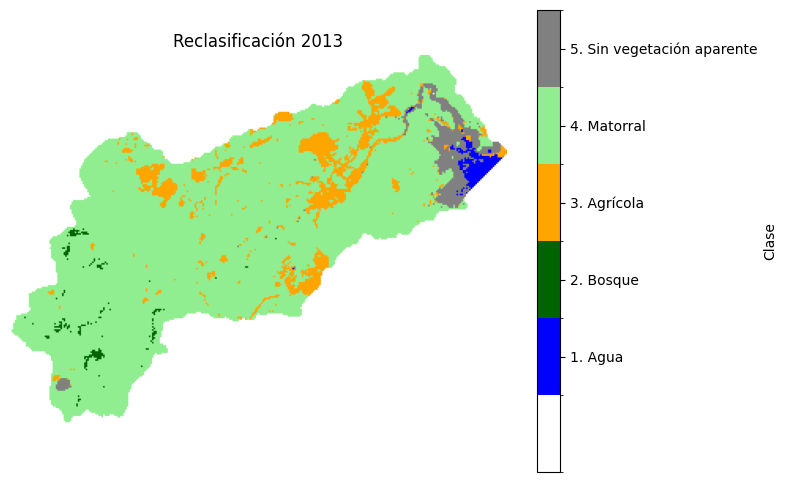

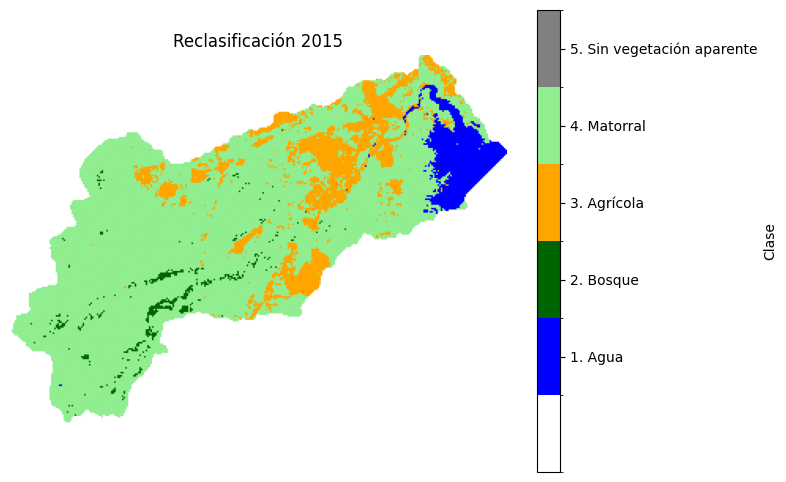

In [ ]:
# @title
ruta_raster_1 = '/content/drive/MyDrive/EarthEngine/reclas_zona5_2013_X.tif'
ruta_raster_2 = '/content/drive/MyDrive/EarthEngine/reclas_zona5_2015_X.tif'

nombre_raster_1 = '2013'
nombre_raster_2 = '2015'
zona = 'zona - 5'

periodo_anios = 2

carpeta_salida = '/content/drive/MyDrive/Analisis_cambio_uso_suelo'
os.makedirs(carpeta_salida, exist_ok=True)

salida_excel = os.path.join(
    carpeta_salida,
    f'analisis_cambio_uso_suelo_{nombre_raster_1}_{nombre_raster_2}_{zona}.xlsx'
)

def read_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1)
        nodata = src.nodata
        transform = src.transform
        crs = src.crs
        shape = data.shape
    return data, nodata, transform, crs, shape

raster_1, nodata_1, transform_1, crs_1, shape_1 = read_raster(ruta_raster_1)
raster_2, nodata_2, transform_2, crs_2, shape_2 = read_raster(ruta_raster_2)

if shape_1 != shape_2:
    raise ValueError("Los raster no tienen el mismo tamaño.")

if transform_1 != transform_2:
    print("Advertencia: los raster tienen diferente alineación espacial o resolución.")

if crs_1 != crs_2:
    print("Advertencia: los raster tienen diferente sistema de coordenadas.")


flat_1 = raster_1.flatten()
flat_2 = raster_2.flatten()

mask = (flat_1 > 0) & (flat_2 > 0)

if nodata_1 is not None:
    mask = mask & (flat_1 != nodata_1)

if nodata_2 is not None:
    mask = mask & (flat_2 != nodata_2)

flat_1 = flat_1[mask]
flat_2 = flat_2[mask]

clases = np.unique(np.concatenate((flat_1, flat_2)))
clases.sort()

n = len(clases)
clase_dict = {v: i for i, v in enumerate(clases)}

matriz = np.zeros((n, n), dtype=int)

for c1, c2 in zip(flat_1, flat_2):
    i = clase_dict[c1]
    j = clase_dict[c2]
    matriz[i, j] += 1

df_matriz_pixeles = pd.DataFrame(
    matriz,
    index=[f'Clase {int(c)}' for c in clases],
    columns=[f'Clase {int(c)}' for c in clases]
)

pixel_area_ha = 30 * 30 / 10000
matriz_ha = matriz * pixel_area_ha

df_matriz_ha = pd.DataFrame(
    matriz_ha,
    index=[f'Clase {int(c)}' for c in clases],
    columns=[f'Clase {int(c)}' for c in clases]
)

resultados = []

for i, clase in enumerate(clases):
    fila = matriz[i, :]
    col = matriz[:, i]

    inicial = fila.sum()
    final = col.sum()
    persistencia = matriz[i, i]
    perdida = inicial - persistencia
    ganancia = final - persistencia
    cambio_neto = ganancia - perdida
    cambio_total = ganancia + perdida

    porcentaje_cambio = cambio_total / inicial * 100 if inicial > 0 else 0
    tasa_anual = porcentaje_cambio / periodo_anios if periodo_anios > 0 else 0

    resultados.append({
        'Clase': int(clase),
        'Área Inicial (ha)': inicial * pixel_area_ha,
        'Área Final (ha)': final * pixel_area_ha,
        'Persistencia (ha)': persistencia * pixel_area_ha,
        'Pérdida (ha)': perdida * pixel_area_ha,
        'Ganancia (ha)': ganancia * pixel_area_ha,
        'Cambio Neto (ha)': cambio_neto * pixel_area_ha,
        'Cambio Total (ha)': cambio_total * pixel_area_ha,
        '% de Cambio': porcentaje_cambio,
        'Tasa Anual (%)': tasa_anual
    })

df_resultados = pd.DataFrame(resultados).set_index('Clase')

print(f"\n MATRIZ DE TRANSICIÓN {nombre_raster_1}–{nombre_raster_2} (pixeles):")
display(df_matriz_pixeles)

print(f"\n MATRIZ DE TRANSICIÓN {nombre_raster_1}–{nombre_raster_2} (ha):")
display(df_matriz_ha.round(2))

print(f"\n TABLA RESUMEN DE CAMBIOS {nombre_raster_1}–{nombre_raster_2}:")
display(df_resultados.round(2))

with pd.ExcelWriter(salida_excel, engine='openpyxl') as writer:
    df_matriz_pixeles.to_excel(writer, sheet_name='Matriz_transicion_pixeles')
    df_matriz_ha.round(4).to_excel(writer, sheet_name='Matriz_transicion_ha')
    df_resultados.round(4).to_excel(writer, sheet_name='Resumen_cambios')

print("Archivo Excel exportado correctamente en:")
print(salida_excel)

colores = [
    'white',
    'blue',
    'darkgreen',
    'orange',
    'lightgreen',
    'gray'
]

etiquetas = [
    '1. Agua',
    '2. Bosque',
    '3. Agrícola',
    '4. Matorral',
    '5. Sin vegetación aparente'
]

cmap = ListedColormap(colores)
boundaries = np.arange(0, 7) - 0.5
norm = BoundaryNorm(boundaries, cmap.N)

def plot_classification_colored(data, title):
    plt.figure(figsize=(8, 6))
    im = plt.imshow(data, cmap=cmap, norm=norm)
    cbar = plt.colorbar(im, ticks=np.arange(1, 6))
    cbar.set_label('Clase')
    cbar.ax.set_yticklabels(etiquetas)
    plt.title(title)
    plt.axis('off')
    plt.show()

plot_classification_colored(raster_1, f'Reclasificación {nombre_raster_1}')
plot_classification_colored(raster_2, f'Reclasificación {nombre_raster_2}')

#Analisis de cambio de uso de suelo ZONA 5 2015-2017


 MATRIZ DE TRANSICIÓN 2015–2017 (pixeles):


,Clase 1,Clase 2,Clase 3,Clase 4,Clase 5
Clase 1,1826,0,26,14,46
Clase 2,0,144,5,403,0
Clase 3,39,0,3582,999,9
Clase 4,344,458,2340,22103,34
Clase 5,0,0,3,0,0



 MATRIZ DE TRANSICIÓN 2015–2017 (ha):


,Clase 1,Clase 2,Clase 3,Clase 4,Clase 5
Clase 1,164.34,0.00,2.34,1.26,4.14
Clase 2,0.00,12.96,0.45,36.27,0.00
Clase 3,3.51,0.00,322.38,89.91,0.81
Clase 4,30.96,41.22,210.60,1989.27,3.06
Clase 5,0.00,0.00,0.27,0.00,0.00



 TABLA RESUMEN DE CAMBIOS 2015–2017:


,Área Inicial (ha),Área Final (ha),Persistencia (ha),Pérdida (ha),Ganancia (ha),Cambio Neto (ha),Cambio Total (ha),% de Cambio,Tasa Anual (%)
Clase,,,,,,,,,
1,172.08,198.81,164.34,7.74,34.47,26.73,42.21,24.53,12.26
2,49.68,54.18,12.96,36.72,41.22,4.50,77.94,156.88,78.44
3,416.61,536.04,322.38,94.23,213.66,119.43,307.89,73.90,36.95
4,2275.11,2116.71,1989.27,285.84,127.44,-158.40,413.28,18.17,9.08
5,0.27,8.01,0.00,0.27,8.01,7.74,8.28,3066.67,1533.33


Archivo Excel exportado correctamente en:
/content/drive/MyDrive/Analisis_cambio_uso_suelo/analisis_cambio_uso_suelo_2015_2017_zona - 5.xlsx


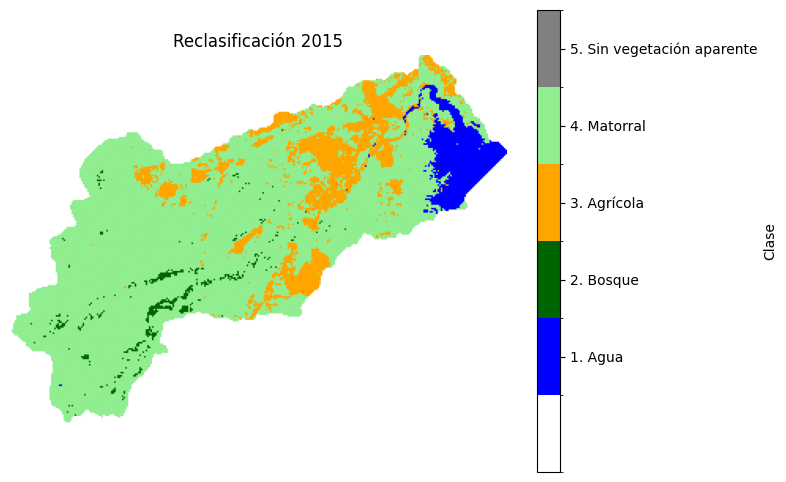

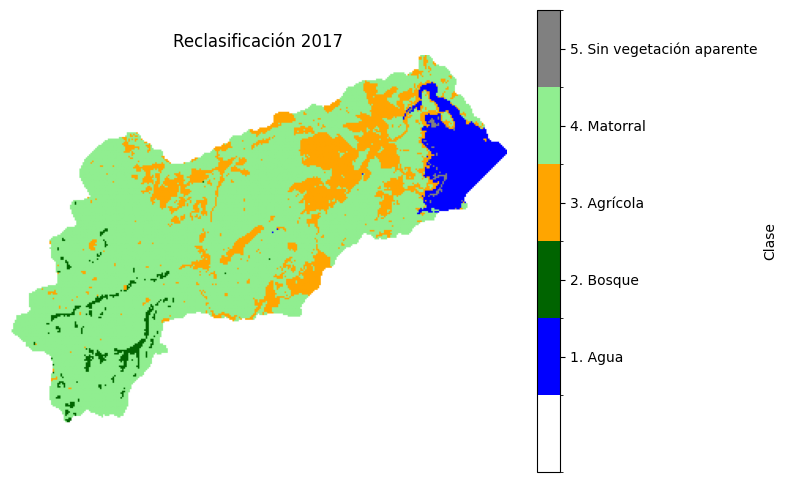

In [ ]:
# @title
ruta_raster_1 = '/content/drive/MyDrive/EarthEngine/reclas_zona5_2015_X.tif'
ruta_raster_2 = '/content/drive/MyDrive/EarthEngine/reclas_zona5_2017_X.tif'

nombre_raster_1 = '2015'
nombre_raster_2 = '2017'
zona = 'zona - 5'

periodo_anios = 2

carpeta_salida = '/content/drive/MyDrive/Analisis_cambio_uso_suelo'
os.makedirs(carpeta_salida, exist_ok=True)

salida_excel = os.path.join(
    carpeta_salida,
    f'analisis_cambio_uso_suelo_{nombre_raster_1}_{nombre_raster_2}_{zona}.xlsx'
)

def read_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1)
        nodata = src.nodata
        transform = src.transform
        crs = src.crs
        shape = data.shape
    return data, nodata, transform, crs, shape

raster_1, nodata_1, transform_1, crs_1, shape_1 = read_raster(ruta_raster_1)
raster_2, nodata_2, transform_2, crs_2, shape_2 = read_raster(ruta_raster_2)

if shape_1 != shape_2:
    raise ValueError("Los raster no tienen el mismo tamaño.")

if transform_1 != transform_2:
    print("Advertencia: los raster tienen diferente alineación espacial o resolución.")

if crs_1 != crs_2:
    print("Advertencia: los raster tienen diferente sistema de coordenadas.")


flat_1 = raster_1.flatten()
flat_2 = raster_2.flatten()

mask = (flat_1 > 0) & (flat_2 > 0)

if nodata_1 is not None:
    mask = mask & (flat_1 != nodata_1)

if nodata_2 is not None:
    mask = mask & (flat_2 != nodata_2)

flat_1 = flat_1[mask]
flat_2 = flat_2[mask]

clases = np.unique(np.concatenate((flat_1, flat_2)))
clases.sort()

n = len(clases)
clase_dict = {v: i for i, v in enumerate(clases)}

matriz = np.zeros((n, n), dtype=int)

for c1, c2 in zip(flat_1, flat_2):
    i = clase_dict[c1]
    j = clase_dict[c2]
    matriz[i, j] += 1

df_matriz_pixeles = pd.DataFrame(
    matriz,
    index=[f'Clase {int(c)}' for c in clases],
    columns=[f'Clase {int(c)}' for c in clases]
)

pixel_area_ha = 30 * 30 / 10000
matriz_ha = matriz * pixel_area_ha

df_matriz_ha = pd.DataFrame(
    matriz_ha,
    index=[f'Clase {int(c)}' for c in clases],
    columns=[f'Clase {int(c)}' for c in clases]
)

resultados = []

for i, clase in enumerate(clases):
    fila = matriz[i, :]
    col = matriz[:, i]

    inicial = fila.sum()
    final = col.sum()
    persistencia = matriz[i, i]
    perdida = inicial - persistencia
    ganancia = final - persistencia
    cambio_neto = ganancia - perdida
    cambio_total = ganancia + perdida

    porcentaje_cambio = cambio_total / inicial * 100 if inicial > 0 else 0
    tasa_anual = porcentaje_cambio / periodo_anios if periodo_anios > 0 else 0

    resultados.append({
        'Clase': int(clase),
        'Área Inicial (ha)': inicial * pixel_area_ha,
        'Área Final (ha)': final * pixel_area_ha,
        'Persistencia (ha)': persistencia * pixel_area_ha,
        'Pérdida (ha)': perdida * pixel_area_ha,
        'Ganancia (ha)': ganancia * pixel_area_ha,
        'Cambio Neto (ha)': cambio_neto * pixel_area_ha,
        'Cambio Total (ha)': cambio_total * pixel_area_ha,
        '% de Cambio': porcentaje_cambio,
        'Tasa Anual (%)': tasa_anual
    })

df_resultados = pd.DataFrame(resultados).set_index('Clase')

print(f"\n MATRIZ DE TRANSICIÓN {nombre_raster_1}–{nombre_raster_2} (pixeles):")
display(df_matriz_pixeles)

print(f"\n MATRIZ DE TRANSICIÓN {nombre_raster_1}–{nombre_raster_2} (ha):")
display(df_matriz_ha.round(2))

print(f"\n TABLA RESUMEN DE CAMBIOS {nombre_raster_1}–{nombre_raster_2}:")
display(df_resultados.round(2))

with pd.ExcelWriter(salida_excel, engine='openpyxl') as writer:
    df_matriz_pixeles.to_excel(writer, sheet_name='Matriz_transicion_pixeles')
    df_matriz_ha.round(4).to_excel(writer, sheet_name='Matriz_transicion_ha')
    df_resultados.round(4).to_excel(writer, sheet_name='Resumen_cambios')

print("Archivo Excel exportado correctamente en:")
print(salida_excel)

colores = [
    'white',
    'blue',
    'darkgreen',
    'orange',
    'lightgreen',
    'gray'
]

etiquetas = [
    '1. Agua',
    '2. Bosque',
    '3. Agrícola',
    '4. Matorral',
    '5. Sin vegetación aparente'
]

cmap = ListedColormap(colores)
boundaries = np.arange(0, 7) - 0.5
norm = BoundaryNorm(boundaries, cmap.N)

def plot_classification_colored(data, title):
    plt.figure(figsize=(8, 6))
    im = plt.imshow(data, cmap=cmap, norm=norm)
    cbar = plt.colorbar(im, ticks=np.arange(1, 6))
    cbar.set_label('Clase')
    cbar.ax.set_yticklabels(etiquetas)
    plt.title(title)
    plt.axis('off')
    plt.show()

plot_classification_colored(raster_1, f'Reclasificación {nombre_raster_1}')
plot_classification_colored(raster_2, f'Reclasificación {nombre_raster_2}')

#Analisis de cambio de uso de suelo ZONA 6 2013-2015


 MATRIZ DE TRANSICIÓN 2013–2015 (pixeles):


,Clase 1,Clase 2,Clase 3,Clase 4,Clase 5
Clase 1,836,0,0,0,0
Clase 2,0,21,0,25,0
Clase 3,390,0,779,279,0
Clase 4,642,436,543,16709,0
Clase 5,1273,0,8,20,0



 MATRIZ DE TRANSICIÓN 2013–2015 (ha):


,Clase 1,Clase 2,Clase 3,Clase 4,Clase 5
Clase 1,75.24,0.00,0.00,0.00,0.0
Clase 2,0.00,1.89,0.00,2.25,0.0
Clase 3,35.10,0.00,70.11,25.11,0.0
Clase 4,57.78,39.24,48.87,1503.81,0.0
Clase 5,114.57,0.00,0.72,1.80,0.0



 TABLA RESUMEN DE CAMBIOS 2013–2015:


,Área Inicial (ha),Área Final (ha),Persistencia (ha),Pérdida (ha),Ganancia (ha),Cambio Neto (ha),Cambio Total (ha),% de Cambio,Tasa Anual (%)
Clase,,,,,,,,,
1,75.24,282.69,75.24,0.00,207.45,207.45,207.45,275.72,137.86
2,4.14,41.13,1.89,2.25,39.24,36.99,41.49,1002.17,501.09
3,130.32,119.70,70.11,60.21,49.59,-10.62,109.80,84.25,42.13
4,1649.70,1532.97,1503.81,145.89,29.16,-116.73,175.05,10.61,5.31
5,117.09,0.00,0.00,117.09,0.00,-117.09,117.09,100.00,50.00


Archivo Excel exportado correctamente en:
/content/drive/MyDrive/Analisis_cambio_uso_suelo/analisis_cambio_uso_suelo_2013_2015_zona - 6.xlsx


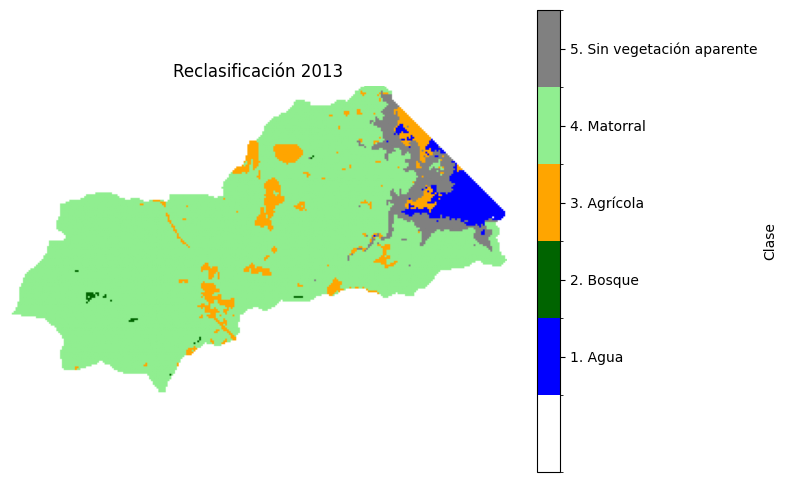

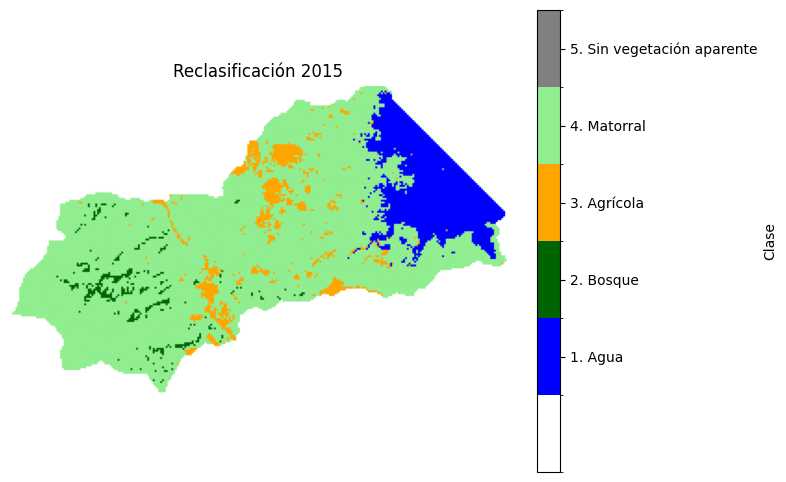

In [ ]:
# @title
ruta_raster_1 = '/content/drive/MyDrive/EarthEngine/reclas_zona6_2013_X.tif'
ruta_raster_2 = '/content/drive/MyDrive/EarthEngine/reclas_zona6_2015_X.tif'

nombre_raster_1 = '2013'
nombre_raster_2 = '2015'
zona = 'zona - 6'

periodo_anios = 2

carpeta_salida = '/content/drive/MyDrive/Analisis_cambio_uso_suelo'
os.makedirs(carpeta_salida, exist_ok=True)

salida_excel = os.path.join(
    carpeta_salida,
    f'analisis_cambio_uso_suelo_{nombre_raster_1}_{nombre_raster_2}_{zona}.xlsx'
)

def read_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1)
        nodata = src.nodata
        transform = src.transform
        crs = src.crs
        shape = data.shape
    return data, nodata, transform, crs, shape

raster_1, nodata_1, transform_1, crs_1, shape_1 = read_raster(ruta_raster_1)
raster_2, nodata_2, transform_2, crs_2, shape_2 = read_raster(ruta_raster_2)

if shape_1 != shape_2:
    raise ValueError("Los raster no tienen el mismo tamaño.")

if transform_1 != transform_2:
    print("Advertencia: los raster tienen diferente alineación espacial o resolución.")

if crs_1 != crs_2:
    print("Advertencia: los raster tienen diferente sistema de coordenadas.")


flat_1 = raster_1.flatten()
flat_2 = raster_2.flatten()

mask = (flat_1 > 0) & (flat_2 > 0)

if nodata_1 is not None:
    mask = mask & (flat_1 != nodata_1)

if nodata_2 is not None:
    mask = mask & (flat_2 != nodata_2)

flat_1 = flat_1[mask]
flat_2 = flat_2[mask]

clases = np.unique(np.concatenate((flat_1, flat_2)))
clases.sort()

n = len(clases)
clase_dict = {v: i for i, v in enumerate(clases)}

matriz = np.zeros((n, n), dtype=int)

for c1, c2 in zip(flat_1, flat_2):
    i = clase_dict[c1]
    j = clase_dict[c2]
    matriz[i, j] += 1

df_matriz_pixeles = pd.DataFrame(
    matriz,
    index=[f'Clase {int(c)}' for c in clases],
    columns=[f'Clase {int(c)}' for c in clases]
)

pixel_area_ha = 30 * 30 / 10000
matriz_ha = matriz * pixel_area_ha

df_matriz_ha = pd.DataFrame(
    matriz_ha,
    index=[f'Clase {int(c)}' for c in clases],
    columns=[f'Clase {int(c)}' for c in clases]
)

resultados = []

for i, clase in enumerate(clases):
    fila = matriz[i, :]
    col = matriz[:, i]

    inicial = fila.sum()
    final = col.sum()
    persistencia = matriz[i, i]
    perdida = inicial - persistencia
    ganancia = final - persistencia
    cambio_neto = ganancia - perdida
    cambio_total = ganancia + perdida

    porcentaje_cambio = cambio_total / inicial * 100 if inicial > 0 else 0
    tasa_anual = porcentaje_cambio / periodo_anios if periodo_anios > 0 else 0

    resultados.append({
        'Clase': int(clase),
        'Área Inicial (ha)': inicial * pixel_area_ha,
        'Área Final (ha)': final * pixel_area_ha,
        'Persistencia (ha)': persistencia * pixel_area_ha,
        'Pérdida (ha)': perdida * pixel_area_ha,
        'Ganancia (ha)': ganancia * pixel_area_ha,
        'Cambio Neto (ha)': cambio_neto * pixel_area_ha,
        'Cambio Total (ha)': cambio_total * pixel_area_ha,
        '% de Cambio': porcentaje_cambio,
        'Tasa Anual (%)': tasa_anual
    })

df_resultados = pd.DataFrame(resultados).set_index('Clase')

print(f"\n MATRIZ DE TRANSICIÓN {nombre_raster_1}–{nombre_raster_2} (pixeles):")
display(df_matriz_pixeles)

print(f"\n MATRIZ DE TRANSICIÓN {nombre_raster_1}–{nombre_raster_2} (ha):")
display(df_matriz_ha.round(2))

print(f"\n TABLA RESUMEN DE CAMBIOS {nombre_raster_1}–{nombre_raster_2}:")
display(df_resultados.round(2))

with pd.ExcelWriter(salida_excel, engine='openpyxl') as writer:
    df_matriz_pixeles.to_excel(writer, sheet_name='Matriz_transicion_pixeles')
    df_matriz_ha.round(4).to_excel(writer, sheet_name='Matriz_transicion_ha')
    df_resultados.round(4).to_excel(writer, sheet_name='Resumen_cambios')

print("Archivo Excel exportado correctamente en:")
print(salida_excel)

colores = [
    'white',
    'blue',
    'darkgreen',
    'orange',
    'lightgreen',
    'gray'
]

etiquetas = [
    '1. Agua',
    '2. Bosque',
    '3. Agrícola',
    '4. Matorral',
    '5. Sin vegetación aparente'
]

cmap = ListedColormap(colores)
boundaries = np.arange(0, 7) - 0.5
norm = BoundaryNorm(boundaries, cmap.N)

def plot_classification_colored(data, title):
    plt.figure(figsize=(8, 6))
    im = plt.imshow(data, cmap=cmap, norm=norm)
    cbar = plt.colorbar(im, ticks=np.arange(1, 6))
    cbar.set_label('Clase')
    cbar.ax.set_yticklabels(etiquetas)
    plt.title(title)
    plt.axis('off')
    plt.show()

plot_classification_colored(raster_1, f'Reclasificación {nombre_raster_1}')
plot_classification_colored(raster_2, f'Reclasificación {nombre_raster_2}')

#Analisis de cambio de uso de suelo ZONA 6 2015-2017


 MATRIZ DE TRANSICIÓN 2015–2017 (pixeles):


,Clase 1,Clase 2,Clase 3,Clase 4,Clase 5
Clase 1,2995,0,68,37,42
Clase 2,0,102,3,352,0
Clase 3,14,0,979,334,3
Clase 4,575,393,1632,14427,6
Clase 5,0,0,0,0,0



 MATRIZ DE TRANSICIÓN 2015–2017 (ha):


,Clase 1,Clase 2,Clase 3,Clase 4,Clase 5
Clase 1,269.55,0.00,6.12,3.33,3.78
Clase 2,0.00,9.18,0.27,31.68,0.00
Clase 3,1.26,0.00,88.11,30.06,0.27
Clase 4,51.75,35.37,146.88,1298.43,0.54
Clase 5,0.00,0.00,0.00,0.00,0.00



 TABLA RESUMEN DE CAMBIOS 2015–2017:


,Área Inicial (ha),Área Final (ha),Persistencia (ha),Pérdida (ha),Ganancia (ha),Cambio Neto (ha),Cambio Total (ha),% de Cambio,Tasa Anual (%)
Clase,,,,,,,,,
1,282.78,322.56,269.55,13.23,53.01,39.78,66.24,23.42,11.71
2,41.13,44.55,9.18,31.95,35.37,3.42,67.32,163.68,81.84
3,119.70,241.38,88.11,31.59,153.27,121.68,184.86,154.44,77.22
4,1532.97,1363.50,1298.43,234.54,65.07,-169.47,299.61,19.54,9.77
5,0.00,4.59,0.00,0.00,4.59,4.59,4.59,0.00,0.00


Archivo Excel exportado correctamente en:
/content/drive/MyDrive/Analisis_cambio_uso_suelo/analisis_cambio_uso_suelo_2015_2017_zona - 6.xlsx


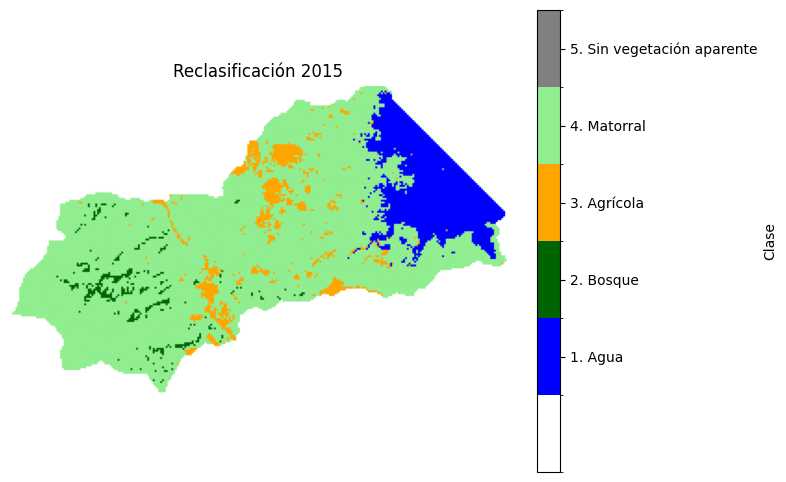

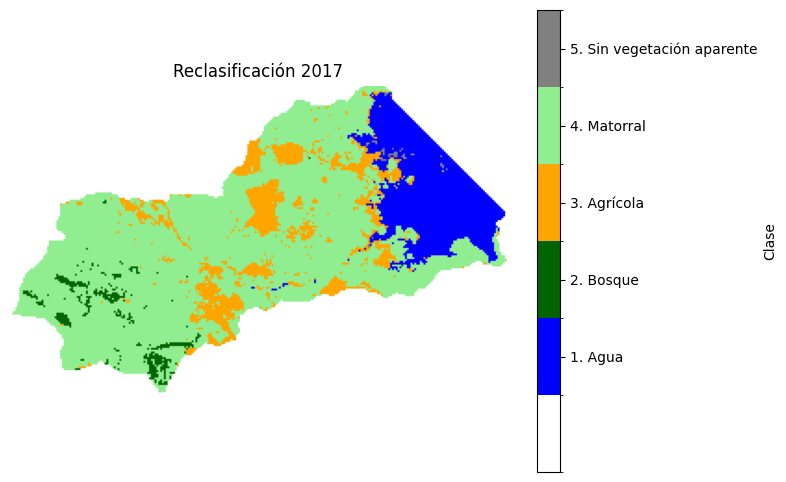

In [ ]:
# @title
ruta_raster_1 = '/content/drive/MyDrive/EarthEngine/reclas_zona6_2015_X.tif'
ruta_raster_2 = '/content/drive/MyDrive/EarthEngine/reclas_zona6_2017_X.tif'

nombre_raster_1 = '2015'
nombre_raster_2 = '2017'
zona = 'zona - 6'

periodo_anios = 2

carpeta_salida = '/content/drive/MyDrive/Analisis_cambio_uso_suelo'
os.makedirs(carpeta_salida, exist_ok=True)

salida_excel = os.path.join(
    carpeta_salida,
    f'analisis_cambio_uso_suelo_{nombre_raster_1}_{nombre_raster_2}_{zona}.xlsx'
)

def read_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1)
        nodata = src.nodata
        transform = src.transform
        crs = src.crs
        shape = data.shape
    return data, nodata, transform, crs, shape

raster_1, nodata_1, transform_1, crs_1, shape_1 = read_raster(ruta_raster_1)
raster_2, nodata_2, transform_2, crs_2, shape_2 = read_raster(ruta_raster_2)

if shape_1 != shape_2:
    raise ValueError("Los raster no tienen el mismo tamaño.")

if transform_1 != transform_2:
    print("Advertencia: los raster tienen diferente alineación espacial o resolución.")

if crs_1 != crs_2:
    print("Advertencia: los raster tienen diferente sistema de coordenadas.")


flat_1 = raster_1.flatten()
flat_2 = raster_2.flatten()

mask = (flat_1 > 0) & (flat_2 > 0)

if nodata_1 is not None:
    mask = mask & (flat_1 != nodata_1)

if nodata_2 is not None:
    mask = mask & (flat_2 != nodata_2)

flat_1 = flat_1[mask]
flat_2 = flat_2[mask]

clases = np.unique(np.concatenate((flat_1, flat_2)))
clases.sort()

n = len(clases)
clase_dict = {v: i for i, v in enumerate(clases)}

matriz = np.zeros((n, n), dtype=int)

for c1, c2 in zip(flat_1, flat_2):
    i = clase_dict[c1]
    j = clase_dict[c2]
    matriz[i, j] += 1

df_matriz_pixeles = pd.DataFrame(
    matriz,
    index=[f'Clase {int(c)}' for c in clases],
    columns=[f'Clase {int(c)}' for c in clases]
)

pixel_area_ha = 30 * 30 / 10000
matriz_ha = matriz * pixel_area_ha

df_matriz_ha = pd.DataFrame(
    matriz_ha,
    index=[f'Clase {int(c)}' for c in clases],
    columns=[f'Clase {int(c)}' for c in clases]
)

resultados = []

for i, clase in enumerate(clases):
    fila = matriz[i, :]
    col = matriz[:, i]

    inicial = fila.sum()
    final = col.sum()
    persistencia = matriz[i, i]
    perdida = inicial - persistencia
    ganancia = final - persistencia
    cambio_neto = ganancia - perdida
    cambio_total = ganancia + perdida

    porcentaje_cambio = cambio_total / inicial * 100 if inicial > 0 else 0
    tasa_anual = porcentaje_cambio / periodo_anios if periodo_anios > 0 else 0

    resultados.append({
        'Clase': int(clase),
        'Área Inicial (ha)': inicial * pixel_area_ha,
        'Área Final (ha)': final * pixel_area_ha,
        'Persistencia (ha)': persistencia * pixel_area_ha,
        'Pérdida (ha)': perdida * pixel_area_ha,
        'Ganancia (ha)': ganancia * pixel_area_ha,
        'Cambio Neto (ha)': cambio_neto * pixel_area_ha,
        'Cambio Total (ha)': cambio_total * pixel_area_ha,
        '% de Cambio': porcentaje_cambio,
        'Tasa Anual (%)': tasa_anual
    })

df_resultados = pd.DataFrame(resultados).set_index('Clase')

print(f"\n MATRIZ DE TRANSICIÓN {nombre_raster_1}–{nombre_raster_2} (pixeles):")
display(df_matriz_pixeles)

print(f"\n MATRIZ DE TRANSICIÓN {nombre_raster_1}–{nombre_raster_2} (ha):")
display(df_matriz_ha.round(2))

print(f"\n TABLA RESUMEN DE CAMBIOS {nombre_raster_1}–{nombre_raster_2}:")
display(df_resultados.round(2))

with pd.ExcelWriter(salida_excel, engine='openpyxl') as writer:
    df_matriz_pixeles.to_excel(writer, sheet_name='Matriz_transicion_pixeles')
    df_matriz_ha.round(4).to_excel(writer, sheet_name='Matriz_transicion_ha')
    df_resultados.round(4).to_excel(writer, sheet_name='Resumen_cambios')

print("Archivo Excel exportado correctamente en:")
print(salida_excel)

colores = [
    'white',
    'blue',
    'darkgreen',
    'orange',
    'lightgreen',
    'gray'
]

etiquetas = [
    '1. Agua',
    '2. Bosque',
    '3. Agrícola',
    '4. Matorral',
    '5. Sin vegetación aparente'
]

cmap = ListedColormap(colores)
boundaries = np.arange(0, 7) - 0.5
norm = BoundaryNorm(boundaries, cmap.N)

def plot_classification_colored(data, title):
    plt.figure(figsize=(8, 6))
    im = plt.imshow(data, cmap=cmap, norm=norm)
    cbar = plt.colorbar(im, ticks=np.arange(1, 6))
    cbar.set_label('Clase')
    cbar.ax.set_yticklabels(etiquetas)
    plt.title(title)
    plt.axis('off')
    plt.show()

plot_classification_colored(raster_1, f'Reclasificación {nombre_raster_1}')
plot_classification_colored(raster_2, f'Reclasificación {nombre_raster_2}')